## Notebook 1b. Complete Exploratory Data Analysis (EDA)
### eICU (Training) → MIMIC-III (External Validation)

---

**Project Goal:** Predict ICU mortality using clinical features from the eICU dataset, with external validation on MIMIC-III.

**EDA Sections:**
1. Environmental Setup
2. Data Loading & Schema
3. Dataset Overview (shapes, dtypes, samples)
4. Missingness Analysis
5. Target Analysis — Class Imbalance
6. Demographic Analysis
7. Lab Values — Distributions & Outliers
8. Vital Signs — Distributions
9. Bivariate Analysis — Feature vs Mortality
10. Correlation Analysis
11. Dataset Shift — eICU vs MIMIC

---
# 1. Environmental Setup

In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn imbalanced-learn
!pip install -q xgboost lightgbm shap missingno pyarrow openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import missingno as msno
import warnings, os
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

SEED = 42
np.random.seed(SEED)

# Consistent colour palette
PALETTE = {'eICU': '#4C72B0', 'MIMIC': '#DD8452'}
MORT_PALETTE = {0: '#2ecc71', 1: '#e74c3c'}

print('Environment ready')

Environment ready


In [2]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

EICU_PATH = '/content/drive/MyDrive/AI in Medicine/data/output_data/eicu_train/eicu_features.csv'
# This uses a system command to count the lines in the actual file
!wc -l "{EICU_PATH}"
MIMIC_PATH  = '/content/drive/MyDrive/AI in Medicine/data/output_data/mimic_val/mimic_features.csv'

Mounted at /content/drive
2521 /content/drive/MyDrive/AI in Medicine/data/output_data/eicu_train/eicu_features.csv


---
# 2. Data Loading & Schema

Both CSVs are loaded with `header=0` so column names are read directly from the file — no manual row-dropping or renaming needed.

In [3]:
# --- eICU ---
df_eicu = pd.read_csv(EICU_PATH)

print(f'eICU shape: {df_eicu.shape}')
print('\neICU columns:')
for i, col in enumerate(df_eicu.columns):
    print(f'  [{i:2d}] {col}')

eICU shape: (2520, 73)

eICU columns:
  [ 0] stay_id
  [ 1] age_clean
  [ 2] gender_binary
  [ 3] ethnicity_grp
  [ 4] icu_los_days
  [ 5] careunit
  [ 6] admit_source
  [ 7] mortality
  [ 8] albumin_max
  [ 9] alt_max
  [10] bicarbonate_max
  [11] bun_max
  [12] creatinine_max
  [13] glucose_max
  [14] hematocrit_max
  [15] hemoglobin_max
  [16] inr_max
  [17] lactate_max
  [18] platelets_max
  [19] potassium_max
  [20] sodium_max
  [21] wbc_max
  [22] albumin_mean
  [23] alt_mean
  [24] bicarbonate_mean
  [25] bun_mean
  [26] creatinine_mean
  [27] glucose_mean
  [28] hematocrit_mean
  [29] hemoglobin_mean
  [30] inr_mean
  [31] lactate_mean
  [32] platelets_mean
  [33] potassium_mean
  [34] sodium_mean
  [35] wbc_mean
  [36] albumin_min
  [37] alt_min
  [38] bicarbonate_min
  [39] bun_min
  [40] creatinine_min
  [41] glucose_min
  [42] hematocrit_min
  [43] hemoglobin_min
  [44] inr_min
  [45] lactate_min
  [46] platelets_min
  [47] potassium_min
  [48] sodium_min
  [49] wbc_min
  [

In [4]:
# --- MIMIC ---
df_mimic = pd.read_csv(MIMIC_PATH)

print(f'MIMIC shape: {df_mimic.shape}')
print('\nMIMIC columns:')
for i, col in enumerate(df_mimic.columns):
    print(f'  [{i:2d}] {col}')

MIMIC shape: (136, 74)

MIMIC columns:
  [ 0] stay_id
  [ 1] hadm_id
  [ 2] age_clean
  [ 3] gender_binary
  [ 4] ethnicity_grp
  [ 5] icu_los_days
  [ 6] careunit
  [ 7] admit_source
  [ 8] mortality
  [ 9] albumin_max
  [10] alt_max
  [11] bicarbonate_max
  [12] bun_max
  [13] creatinine_max
  [14] glucose_max
  [15] hematocrit_max
  [16] hemoglobin_max
  [17] inr_max
  [18] lactate_max
  [19] platelets_max
  [20] potassium_max
  [21] sodium_max
  [22] wbc_max
  [23] albumin_mean
  [24] alt_mean
  [25] bicarbonate_mean
  [26] bun_mean
  [27] creatinine_mean
  [28] glucose_mean
  [29] hematocrit_mean
  [30] hemoglobin_mean
  [31] inr_mean
  [32] lactate_mean
  [33] platelets_mean
  [34] potassium_mean
  [35] sodium_mean
  [36] wbc_mean
  [37] albumin_min
  [38] alt_min
  [39] bicarbonate_min
  [40] bun_min
  [41] creatinine_min
  [42] glucose_min
  [43] hematocrit_min
  [44] hemoglobin_min
  [45] inr_min
  [46] lactate_min
  [47] platelets_min
  [48] potassium_min
  [49] sodium_min
  

In [5]:
# ---------------------------------------------------------------------------
# Column harmonisation: rename MIMIC vitals to match eICU naming convention
#   eICU             MIMIC
#   heartrate_*   →  hr_*
#   respiration_* →  rr_*
#   sao2_*        →  spo2_*
#   ssystolic_*   →  sbp_*
#   sdiastolic_*  →  dbp_*
#   systemicmean_ →  map_*
#   temp_*        →  temp_*   (already the same)
# ---------------------------------------------------------------------------

MIMIC_RENAME = {
    'hr_max':  'heartrate_max',  'hr_mean':  'heartrate_mean',  'hr_min':  'heartrate_min',
    'rr_max':  'respiration_max','rr_mean':  'respiration_mean','rr_min':  'respiration_min',
    'spo2_max':'sao2_max',       'spo2_mean':'sao2_mean',       'spo2_min':'sao2_min',
    'sbp_max': 'ssystolic_max',  'sbp_mean': 'ssystolic_mean',  'sbp_min': 'ssystolic_min',
    'dbp_max': 'sdiastolic_max', 'dbp_mean': 'sdiastolic_mean', 'dbp_min': 'sdiastolic_min',
    'map_max': 'systemicmean_max','map_mean':'systemicmean_mean','map_min':'systemicmean_min',
}

df_mimic_aligned = df_mimic.drop(columns=['hadm_id'], errors='ignore').rename(columns=MIMIC_RENAME)

# Reorder MIMIC columns to match eICU (keeps only shared columns)
shared_cols = [c for c in df_eicu.columns if c in df_mimic_aligned.columns]
df_mimic_aligned = df_mimic_aligned[shared_cols]

print(f'Shared columns: {len(shared_cols)}')
print(f'eICU  aligned shape : {df_eicu[shared_cols].shape}')
print(f'MIMIC aligned shape : {df_mimic_aligned.shape}')

# Combine for cross-dataset plots
df_combined = pd.concat([df_eicu[shared_cols], df_mimic_aligned], ignore_index=True)
print(f'Combined shape      : {df_combined.shape}')

Shared columns: 73
eICU  aligned shape : (2520, 73)
MIMIC aligned shape : (136, 73)
Combined shape      : (2656, 73)


---
# 3. Dataset Overview

In [6]:
print('=== eICU — first 3 rows ===')
display(df_eicu.head(3))

print('\n=== MIMIC — first 3 rows ===')
display(df_mimic.head(3))

=== eICU — first 3 rows ===


,stay_id,age_clean,gender_binary,ethnicity_grp,icu_los_days,careunit,admit_source,mortality,albumin_max,alt_max,bicarbonate_max,bun_max,creatinine_max,glucose_max,hematocrit_max,hemoglobin_max,inr_max,lactate_max,platelets_max,potassium_max,sodium_max,wbc_max,albumin_mean,alt_mean,bicarbonate_mean,bun_mean,creatinine_mean,glucose_mean,hematocrit_mean,hemoglobin_mean,inr_mean,lactate_mean,platelets_mean,potassium_mean,sodium_mean,wbc_mean,albumin_min,alt_min,bicarbonate_min,bun_min,creatinine_min,glucose_min,hematocrit_min,hemoglobin_min,inr_min,lactate_min,platelets_min,potassium_min,sodium_min,wbc_min,heartrate_min,heartrate_max,heartrate_mean,respiration_min,respiration_max,respiration_mean,sao2_min,sao2_max,sao2_mean,temp_min,temp_max,temp_mean,ssystolic_min,ssystolic_max,ssystolic_mean,sdiastolic_min,sdiastolic_max,sdiastolic_mean,systemicmean_min,systemicmean_max,systemicmean_mean,icd9_chapter,dataset
0,141764,87.000,0.000,White,0.239,MICU,Unknown,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.000,138.000,106.652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,eicu
1,141765,87.000,0.000,White,1.562,MICU,Unknown,0,NaN,NaN,21.000,28.000,1.040,61.000,37.800,12.300,NaN,NaN,191.000,4.100,139.000,10.200,NaN,NaN,21.000,28.000,1.040,61.000,37.800,12.300,NaN,NaN,191.000,4.100,139.000,10.200,NaN,NaN,21.000,28.000,1.040,61.000,37.800,12.300,NaN,NaN,191.000,4.100,139.000,10.200,72.000,116.000,83.191,17.000,39.000,24.783,95.000,98.000,96.609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,eicu
2,143870,76.000,1.000,White,0.551,SICU,Operating Room,0,NaN,NaN,25.000,14.000,1.140,140.000,34.100,12.300,NaN,NaN,152.000,4.400,139.000,11.700,NaN,NaN,23.500,13.500,1.015,131.500,34.100,12.300,NaN,NaN,152.000,4.400,136.000,11.700,NaN,NaN,22.000,13.000,0.890,123.000,34.100,12.300,NaN,NaN,152.000,4.400,133.000,11.700,40.000,55.000,45.449,45.000,86.000,67.032,80.000,100.000,96.285,NaN,NaN,NaN,53.000,138.000,109.816,36.000,57.000,42.715,47.000,79.000,60.835,Unknown,eicu



=== MIMIC — first 3 rows ===


,stay_id,hadm_id,age_clean,gender_binary,ethnicity_grp,icu_los_days,careunit,admit_source,mortality,albumin_max,alt_max,bicarbonate_max,bun_max,creatinine_max,glucose_max,hematocrit_max,hemoglobin_max,inr_max,lactate_max,platelets_max,potassium_max,sodium_max,wbc_max,albumin_mean,alt_mean,bicarbonate_mean,bun_mean,creatinine_mean,glucose_mean,hematocrit_mean,hemoglobin_mean,inr_mean,lactate_mean,platelets_mean,potassium_mean,sodium_mean,wbc_mean,albumin_min,alt_min,bicarbonate_min,bun_min,creatinine_min,glucose_min,hematocrit_min,hemoglobin_min,inr_min,lactate_min,platelets_min,potassium_min,sodium_min,wbc_min,dbp_max,hr_max,map_max,rr_max,sbp_max,spo2_max,temp_max,dbp_mean,hr_mean,map_mean,rr_mean,sbp_mean,spo2_mean,temp_mean,dbp_min,hr_min,map_min,rr_min,sbp_min,spo2_min,temp_min,icd9_chapter,dataset
0,206504,142345,70.000,0,African,1.633,MICU,Emergency,0,2.700,NaN,31.000,11.000,3.500,84.000,36.900,NaN,3.500,1.300,106.000,4.400,139.000,4.600,2.700,NaN,31.000,11.000,3.500,84.000,36.900,NaN,3.500,1.300,106.000,4.400,139.000,4.600,2.700,NaN,31.000,11.000,3.500,84.000,36.900,NaN,3.500,1.300,106.000,4.400,139.000,4.600,60.000,104.000,80.667,91.000,132.000,100.000,NaN,51.286,86.062,72.810,28.875,115.857,98.533,NaN,45.000,70.000,63.667,15.000,91.000,97.000,NaN,Injury & poisoning,mimic
1,232110,105331,36.000,0,Unknown,13.851,MICU,Transfer,1,2.600,254.000,23.000,3.000,0.700,79.000,34.000,NaN,9.500,NaN,299.000,5.900,136.000,10.600,2.600,254.000,23.000,3.000,0.700,79.000,33.950,NaN,8.667,NaN,299.000,5.900,136.000,10.600,2.600,254.000,23.000,3.000,0.700,79.000,33.900,NaN,7.800,NaN,299.000,5.900,136.000,10.600,71.000,108.000,86.000,23.000,119.000,100.000,NaN,48.542,86.958,67.611,18.833,105.750,98.913,NaN,38.000,72.000,57.667,14.000,97.000,97.000,NaN,Digestive,mimic
2,264446,165520,87.000,0,Unknown,2.650,MICU,Transfer,1,NaN,29.000,29.000,32.000,1.700,165.000,29.200,NaN,1.500,NaN,220.000,4.200,138.000,16.200,NaN,29.000,29.000,32.000,1.700,149.500,28.650,NaN,1.500,NaN,216.500,4.150,137.000,15.000,NaN,29.000,29.000,32.000,1.700,134.000,28.100,NaN,1.500,NaN,213.000,4.100,136.000,13.800,58.000,113.000,91.000,33.000,147.000,96.000,38.500,39.413,98.725,60.468,23.900,110.804,93.385,37.463,28.000,84.000,0.000,18.000,87.000,83.000,36.800,Infectious & parasitic,mimic


In [7]:
def dataset_summary(df, name):
    print(f'\n--- {name} ---')
    print(f'Shape          : {df.shape}')
    print(f'Numeric cols   : {df.select_dtypes(include=np.number).shape[1]}')
    print(f'Categorical cols: {df.select_dtypes(exclude=np.number).shape[1]}')
    print(f'Total missing  : {df.isnull().sum().sum():,} cells ({df.isnull().mean().mean()*100:.1f}% overall)')

dataset_summary(df_eicu,  'eICU  (train)')
dataset_summary(df_mimic, 'MIMIC (test) ')


--- eICU  (train) ---
Shape          : (2520, 73)
Numeric cols   : 68
Categorical cols: 5
Total missing  : 65,047 cells (35.4% overall)

--- MIMIC (test)  ---
Shape          : (136, 74)
Numeric cols   : 69
Categorical cols: 5
Total missing  : 1,800 cells (17.9% overall)


In [8]:
# Numeric summary — eICU
print('=== eICU — numeric summary ===')
display(df_eicu.describe().T.style.background_gradient(cmap='Blues', axis=1))

=== eICU — numeric summary ===


,count,mean,std,min,25%,50%,75%,max
stay_id,2520.000000,1666226.361111,1022223.916469,141764.000000,772262.750000,1590372.500000,2697421.750000,3353113.000000
age_clean,2516.000000,63.281002,17.764847,15.000000,53.000000,66.000000,77.000000,90.000000
gender_binary,2516.000000,0.599364,0.490125,0.000000,0.000000,1.000000,1.000000,1.000000
icu_los_days,2520.000000,2.419497,3.456362,0.000000,0.790104,1.472222,2.776736,46.179861
mortality,2520.000000,0.050000,0.217988,0.000000,0.000000,0.000000,0.000000,1.000000
albumin_max,1051.000000,2.881922,0.684673,0.900000,2.400000,2.900000,3.400000,5.100000
alt_max,941.000000,90.274176,308.322429,5.000000,18.000000,29.000000,53.000000,5610.000000
bicarbonate_max,1944.000000,25.015638,4.924529,4.000000,22.000000,25.000000,27.000000,77.000000
bun_max,2089.000000,25.648880,19.516620,2.000000,13.000000,20.000000,32.000000,212.000000
creatinine_max,2092.000000,1.497870,1.582593,0.100000,0.770000,1.000000,1.560000,20.200000


In [9]:
# Numeric summary — MIMIC
print('=== MIMIC — numeric summary ===')
display(df_mimic.describe().T.style.background_gradient(cmap='Oranges', axis=1))

=== MIMIC — numeric summary ===


,count,mean,std,min,25%,50%,75%,max
stay_id,136.000000,250980.470588,28455.125832,201006.000000,224359.250000,250055.000000,277279.250000,298685.000000
hadm_id,136.000000,153259.566176,28054.220280,100375.000000,129028.000000,157724.000000,174896.500000,199395.000000
age_clean,136.000000,70.382353,16.189644,17.000000,63.000000,74.000000,83.000000,90.000000
gender_binary,136.000000,0.536765,0.500490,0.000000,0.000000,1.000000,1.000000,1.000000
icu_los_days,136.000000,4.452457,6.196828,0.105900,1.233525,2.111450,4.329050,35.406500
mortality,136.000000,0.338235,0.474858,0.000000,0.000000,0.000000,1.000000,1.000000
albumin_max,37.000000,2.967568,0.660830,1.700000,2.400000,3.000000,3.400000,5.200000
alt_max,44.000000,287.295455,925.443516,7.000000,16.000000,25.000000,94.500000,5430.000000
bicarbonate_max,132.000000,25.113636,5.035216,8.000000,22.000000,25.000000,28.000000,42.000000
bun_max,131.000000,31.954198,23.386999,3.000000,16.000000,24.000000,42.500000,126.000000


---
# 4. Missingness Analysis

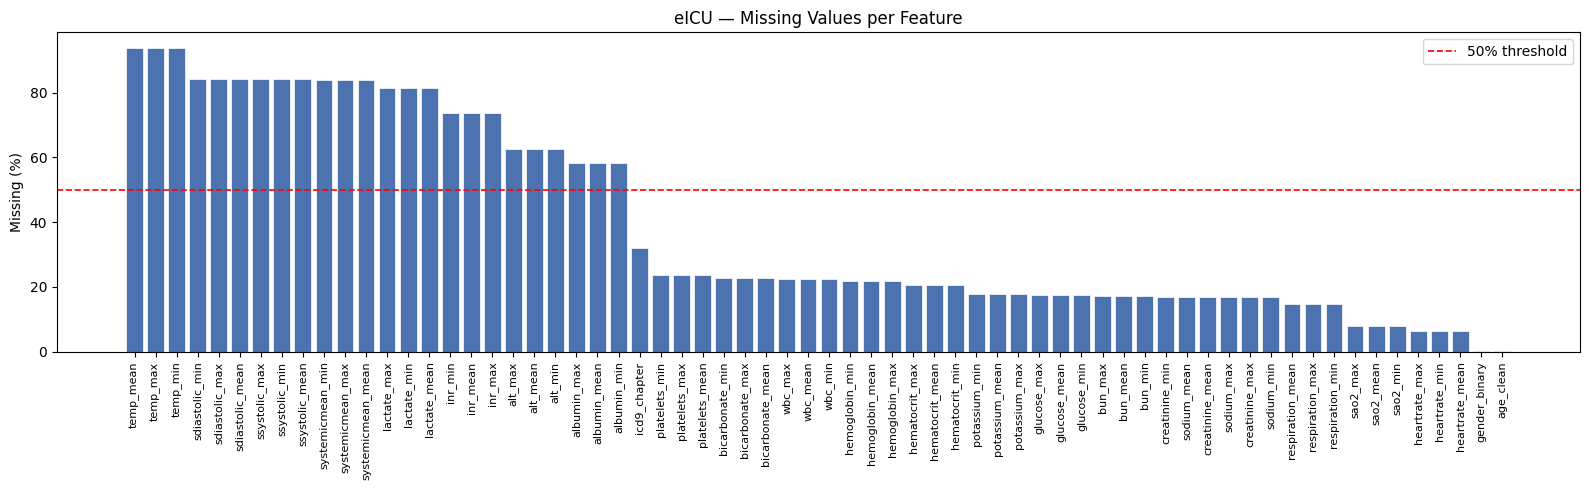


eICU — features with >50% missing:
  temp_mean: 94.0%
  temp_max: 94.0%
  temp_min: 94.0%
  sdiastolic_min: 84.2%
  sdiastolic_max: 84.2%
  sdiastolic_mean: 84.2%
  ssystolic_max: 84.2%
  ssystolic_min: 84.2%
  ssystolic_mean: 84.2%
  systemicmean_min: 84.1%
  systemicmean_max: 84.1%
  systemicmean_mean: 84.1%
  lactate_max: 81.4%
  lactate_min: 81.4%
  lactate_mean: 81.4%
  inr_min: 73.8%
  inr_mean: 73.8%
  inr_max: 73.8%
  alt_max: 62.7%
  alt_mean: 62.7%
  alt_min: 62.7%
  albumin_max: 58.3%
  albumin_mean: 58.3%
  albumin_min: 58.3%


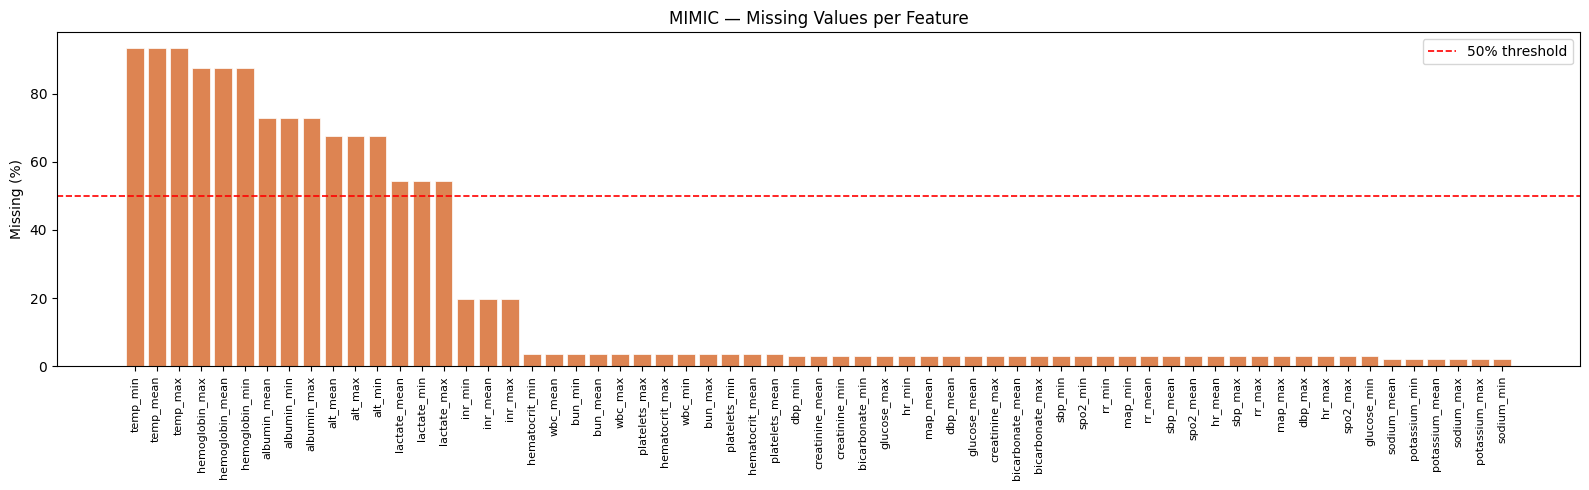


MIMIC — features with >50% missing:
  temp_min: 93.4%
  temp_mean: 93.4%
  temp_max: 93.4%
  hemoglobin_max: 87.5%
  hemoglobin_mean: 87.5%
  hemoglobin_min: 87.5%
  albumin_mean: 72.8%
  albumin_min: 72.8%
  albumin_max: 72.8%
  alt_mean: 67.6%
  alt_max: 67.6%
  alt_min: 67.6%
  lactate_mean: 54.4%
  lactate_min: 54.4%
  lactate_max: 54.4%


In [10]:
def plot_missing_bar(df, name, color):
    missing = df.isnull().mean().sort_values(ascending=False) * 100
    missing = missing[missing > 0]

    fig, ax = plt.subplots(figsize=(16, 5))
    bars = ax.bar(range(len(missing)), missing.values, color=color, edgecolor='white', linewidth=0.5)
    ax.axhline(50, color='red', linestyle='--', linewidth=1.2, label='50% threshold')
    ax.set_xticks(range(len(missing)))
    ax.set_xticklabels(missing.index, rotation=90, fontsize=8)
    ax.set_ylabel('Missing (%)')
    ax.set_title(f'{name} — Missing Values per Feature')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f'\n{name} — features with >50% missing:')
    high_miss = missing[missing > 50]
    if len(high_miss) == 0:
        print('  None')
    else:
        for col, pct in high_miss.items():
            print(f'  {col}: {pct:.1f}%')
    return missing

miss_eicu  = plot_missing_bar(df_eicu,  'eICU',  PALETTE['eICU'])
miss_mimic = plot_missing_bar(df_mimic, 'MIMIC', PALETTE['MIMIC'])

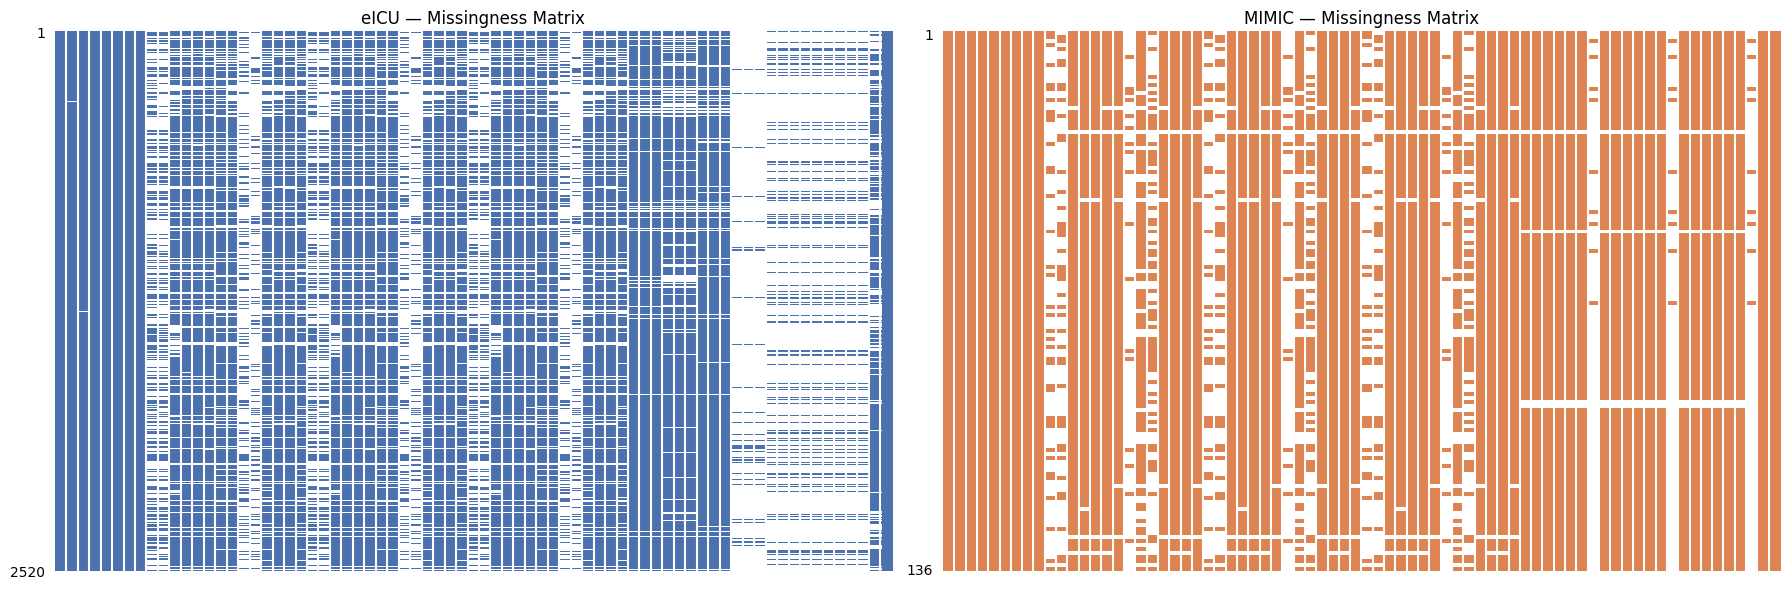

In [11]:
# Missingness matrix — visual pattern of NaN locations
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
msno.matrix(df_eicu,  ax=axes[0], color=(0.298, 0.447, 0.690), fontsize=8)
axes[0].set_title('eICU — Missingness Matrix')
msno.matrix(df_mimic, ax=axes[1], color=(0.867, 0.518, 0.322), fontsize=8)
axes[1].set_title('MIMIC — Missingness Matrix')
plt.tight_layout()
plt.show()

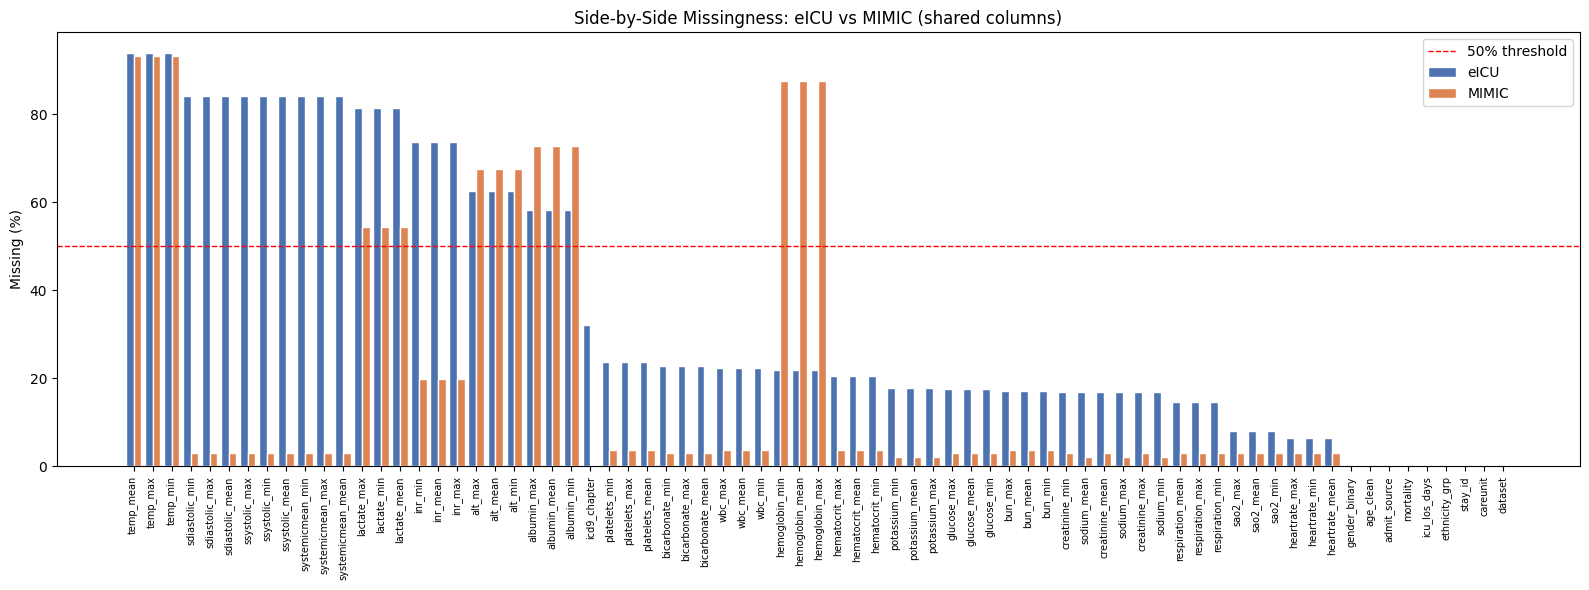

In [12]:
# Compare missingness rates side-by-side for shared columns
miss_df = pd.DataFrame({
    'eICU':  df_eicu[shared_cols].isnull().mean() * 100,
    'MIMIC': df_mimic_aligned.isnull().mean() * 100
}).sort_values('eICU', ascending=False)

fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(miss_df))
w = 0.4
ax.bar(x - w/2, miss_df['eICU'],  w, label='eICU',  color=PALETTE['eICU'],  edgecolor='white')
ax.bar(x + w/2, miss_df['MIMIC'], w, label='MIMIC', color=PALETTE['MIMIC'], edgecolor='white')
ax.axhline(50, color='red', linestyle='--', linewidth=1, label='50% threshold')
ax.set_xticks(x)
ax.set_xticklabels(miss_df.index, rotation=90, fontsize=7)
ax.set_ylabel('Missing (%)')
ax.set_title('Side-by-Side Missingness: eICU vs MIMIC (shared columns)')
ax.legend()
plt.tight_layout()
plt.show()

---
# 5. Target Analysis — Class Imbalance

> **Key note:** The dataset is highly imbalanced. *Accuracy* is a forbidden metric here.  
> Preferred metrics: **AUROC**, **AUPRC**, **Sensitivity (Recall)**, **F1**.

In [13]:
def analyze_mortality(df, name):
    target = pd.to_numeric(df['mortality'], errors='coerce').dropna().astype(int)
    counts     = target.value_counts().sort_index()
    percentage = target.value_counts(normalize=True).sort_index() * 100

    print(f'--- {name} Mortality ---')
    print(f'Total patients : {len(target):,}')
    print(f'Survived  (0)  : {counts.get(0, 0):,}  ({percentage.get(0, 0):.2f}%)')
    print(f'Died      (1)  : {counts.get(1, 0):,}  ({percentage.get(1, 0):.2f}%)')
    print(f'Imbalance ratio: 1 : {counts.get(0, 1)/max(counts.get(1, 1), 1):.1f}')
    print()
    return counts, percentage

eicu_counts,  eicu_pct  = analyze_mortality(df_eicu,  'eICU  (train)')
mimic_counts, mimic_pct = analyze_mortality(df_mimic, 'MIMIC (test) ')

--- eICU  (train) Mortality ---
Total patients : 2,520
Survived  (0)  : 2,394  (95.00%)
Died      (1)  : 126  (5.00%)
Imbalance ratio: 1 : 19.0

--- MIMIC (test)  Mortality ---
Total patients : 136
Survived  (0)  : 90  (66.18%)
Died      (1)  : 46  (33.82%)
Imbalance ratio: 1 : 2.0



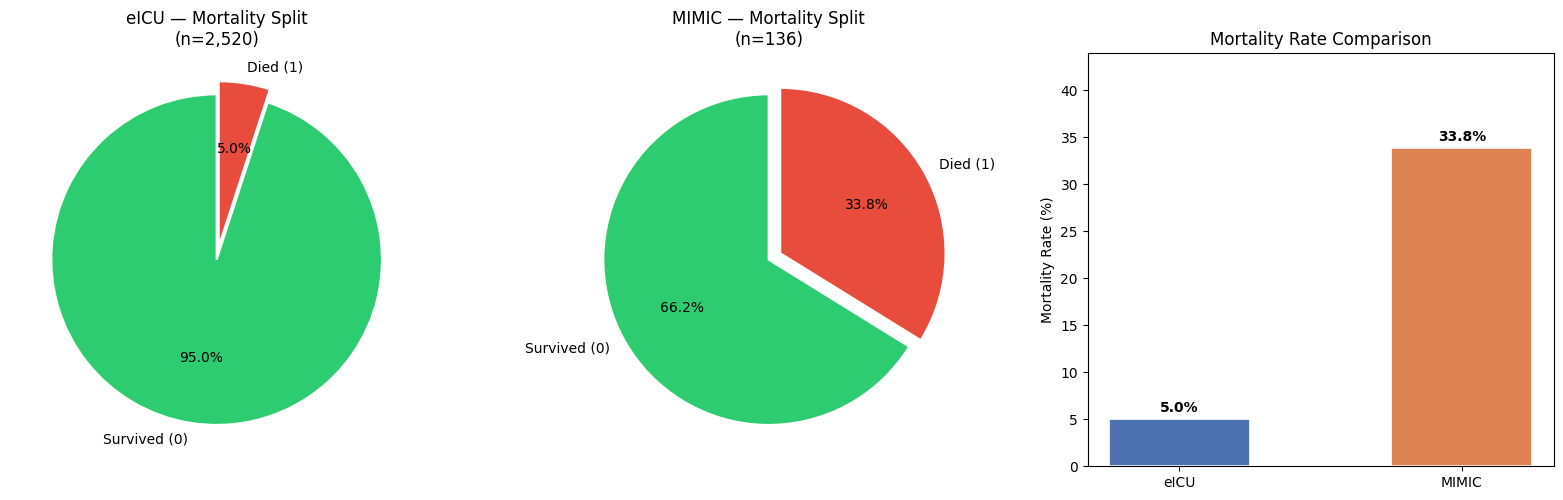

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Pie charts ---
for ax, counts, pct, name, color in [
    (axes[0], eicu_counts,  eicu_pct,  'eICU',  PALETTE['eICU']),
    (axes[1], mimic_counts, mimic_pct, 'MIMIC', PALETTE['MIMIC'])
]:
    labels   = ['Survived (0)', 'Died (1)']
    sizes    = [counts.get(0, 0), counts.get(1, 0)]
    explode  = (0, 0.08)
    colors   = [MORT_PALETTE[0], MORT_PALETTE[1]]
    ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
           explode=explode, colors=colors,
           wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
    ax.set_title(f'{name} — Mortality Split\n(n={sum(sizes):,})')

# --- Grouped bar: mortality rates comparison ---
ax = axes[2]
datasets    = ['eICU', 'MIMIC']
mort_rates  = [eicu_pct.get(1, 0), mimic_pct.get(1, 0)]
bars = ax.bar(datasets, mort_rates,
              color=[PALETTE['eICU'], PALETTE['MIMIC']],
              edgecolor='white', linewidth=1.2, width=0.5)
for bar, rate in zip(bars, mort_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Mortality Rate (%)')
ax.set_title('Mortality Rate Comparison')
ax.set_ylim(0, max(mort_rates) * 1.3)

plt.tight_layout()
plt.show()

---
# 6. Demographic Analysis

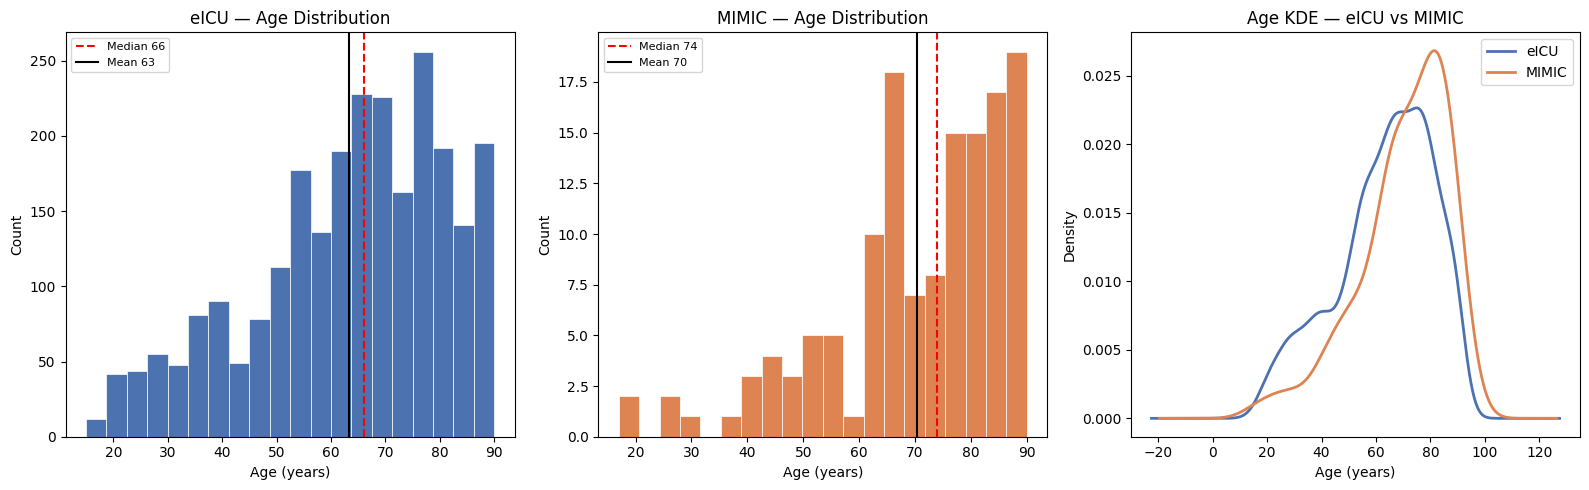

In [15]:
# Age distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, df, name, color in [
    (axes[0], df_eicu,  'eICU',  PALETTE['eICU']),
    (axes[1], df_mimic, 'MIMIC', PALETTE['MIMIC'])
]:
    age = pd.to_numeric(df['age_clean'], errors='coerce').dropna()
    ax.hist(age, bins=20, color=color, edgecolor='white', linewidth=0.5)
    ax.axvline(age.median(), color='red',   linestyle='--', linewidth=1.5, label=f'Median {age.median():.0f}')
    ax.axvline(age.mean(),   color='black', linestyle='-',  linewidth=1.5, label=f'Mean {age.mean():.0f}')
    ax.set_xlabel('Age (years)')
    ax.set_ylabel('Count')
    ax.set_title(f'{name} — Age Distribution')
    ax.legend(fontsize=8)

# Overlay KDE
ax = axes[2]
for df, name, color in [(df_eicu, 'eICU', PALETTE['eICU']), (df_mimic, 'MIMIC', PALETTE['MIMIC'])]:
    age = pd.to_numeric(df['age_clean'], errors='coerce').dropna()
    age.plot.kde(ax=ax, color=color, label=name, linewidth=2)
ax.set_xlabel('Age (years)')
ax.set_title('Age KDE — eICU vs MIMIC')
ax.legend()

plt.tight_layout()
plt.show()

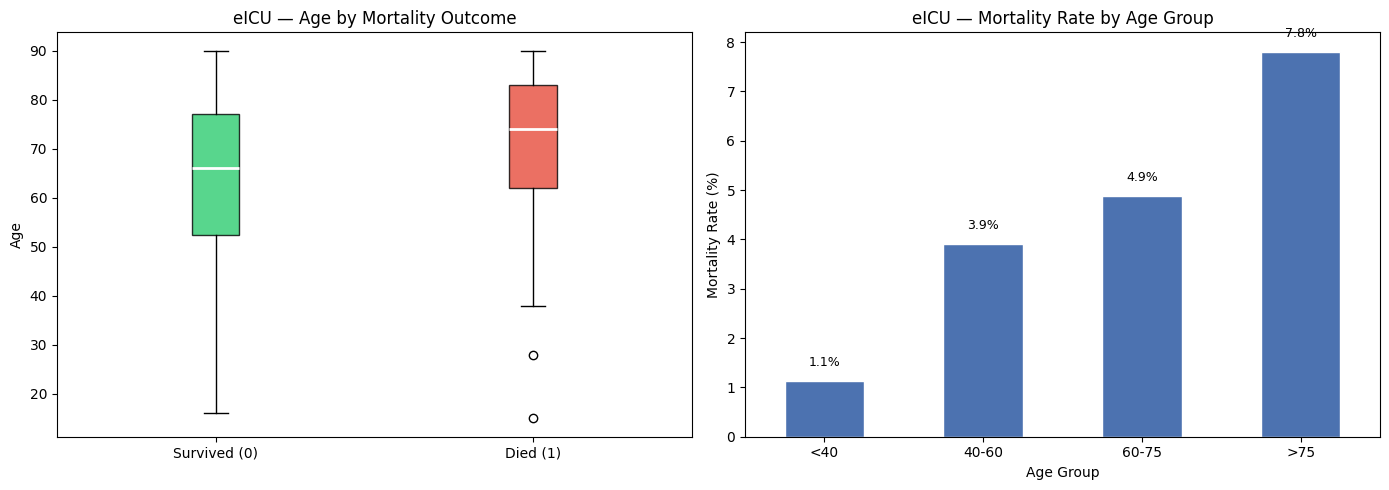

In [16]:
# Age vs Mortality (eICU)
df_eicu['age_num']      = pd.to_numeric(df_eicu['age_clean'], errors='coerce')
df_eicu['mortality_num']= pd.to_numeric(df_eicu['mortality'], errors='coerce').astype('Int64')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
groups = [df_eicu.loc[df_eicu['mortality_num'] == v, 'age_num'].dropna() for v in [0, 1]]
bp = axes[0].boxplot(groups, patch_artist=True, labels=['Survived (0)', 'Died (1)'],
                     medianprops={'color': 'white', 'linewidth': 2})
for patch, color in zip(bp['boxes'], [MORT_PALETTE[0], MORT_PALETTE[1]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0].set_ylabel('Age')
axes[0].set_title('eICU — Age by Mortality Outcome')

# Age groups
bins   = [0, 40, 60, 75, 120]
labels = ['<40', '40-60', '60-75', '>75']
df_eicu['age_group'] = pd.cut(df_eicu['age_num'], bins=bins, labels=labels, right=True)
mort_by_age = df_eicu.groupby('age_group', observed=True)['mortality_num'].mean() * 100
mort_by_age.plot(kind='bar', ax=axes[1], color=PALETTE['eICU'], edgecolor='white')
axes[1].set_ylabel('Mortality Rate (%)')
axes[1].set_title('eICU — Mortality Rate by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].tick_params(axis='x', rotation=0)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

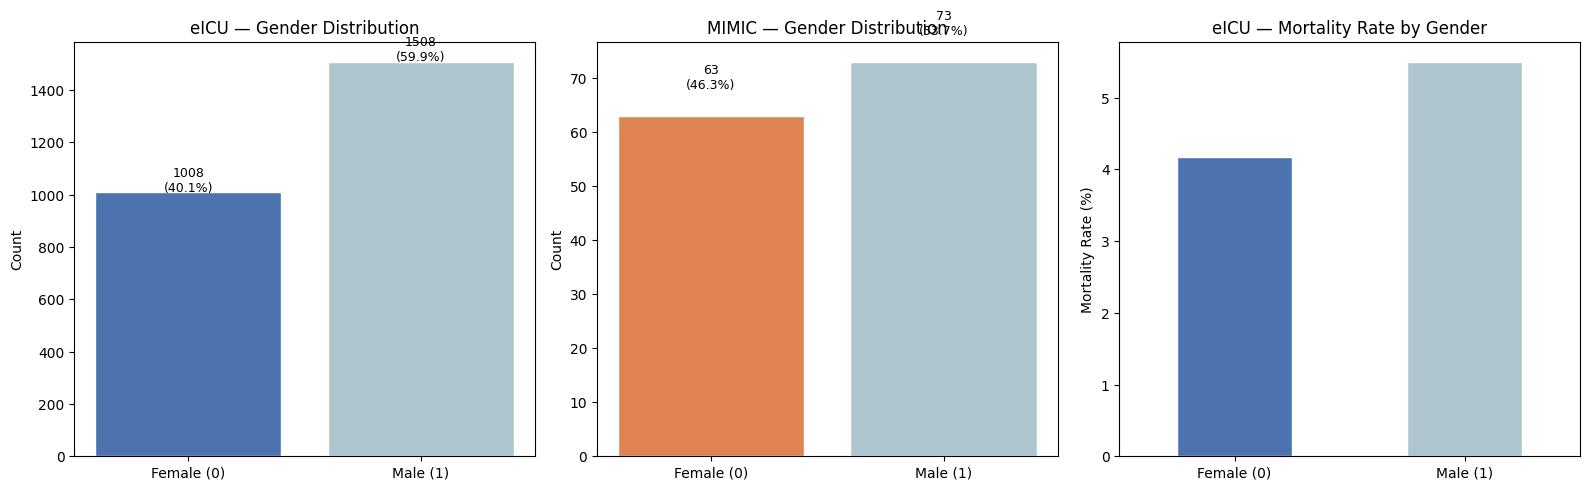

In [17]:
# Gender distribution and mortality rate
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, df, name, color in [
    (axes[0], df_eicu,  'eICU',  PALETTE['eICU']),
    (axes[1], df_mimic, 'MIMIC', PALETTE['MIMIC'])
]:
    gender = pd.to_numeric(df['gender_binary'], errors='coerce').dropna().astype(int)
    counts = gender.value_counts().sort_index()
    ax.bar(['Female (0)', 'Male (1)'], counts.values, color=[color, '#aec6cf'], edgecolor='white')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 5, f'{v}\n({v/sum(counts.values)*100:.1f}%)', ha='center', fontsize=9)
    ax.set_ylabel('Count')
    ax.set_title(f'{name} — Gender Distribution')

# eICU mortality by gender
df_eicu['gender_num'] = pd.to_numeric(df_eicu['gender_binary'], errors='coerce').astype('Int64')
mort_by_gender = df_eicu.groupby('gender_num', observed=True)['mortality_num'].mean() * 100
mort_by_gender.index = ['Female (0)', 'Male (1)']
mort_by_gender.plot(kind='bar', ax=axes[2], color=[PALETTE['eICU'], '#aec6cf'], edgecolor='white')
axes[2].set_ylabel('Mortality Rate (%)')
axes[2].set_title('eICU — Mortality Rate by Gender')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

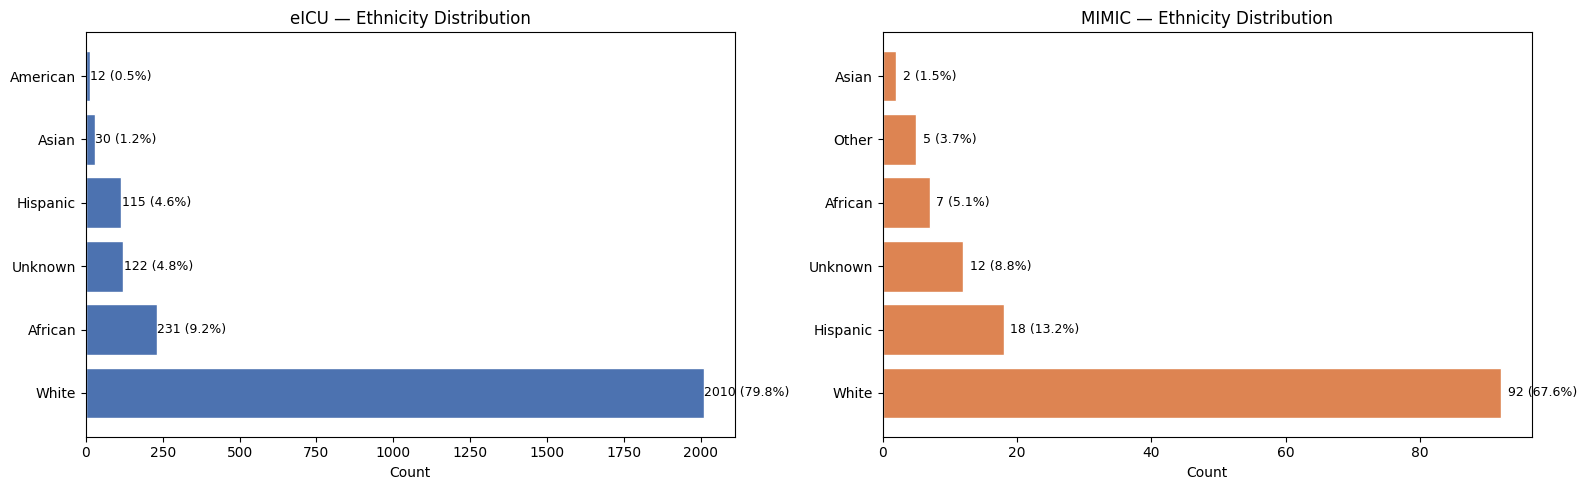

In [18]:
# Ethnicity distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, df, name, color in [
    (axes[0], df_eicu,  'eICU',  PALETTE['eICU']),
    (axes[1], df_mimic, 'MIMIC', PALETTE['MIMIC'])
]:
    eth = df['ethnicity_grp'].dropna().value_counts()
    bars = ax.barh(eth.index, eth.values, color=color, edgecolor='white')
    for bar, v in zip(bars, eth.values):
        ax.text(v + 1, bar.get_y() + bar.get_height()/2,
                f'{v} ({v/eth.sum()*100:.1f}%)', va='center', fontsize=9)
    ax.set_xlabel('Count')
    ax.set_title(f'{name} — Ethnicity Distribution')

plt.tight_layout()
plt.show()

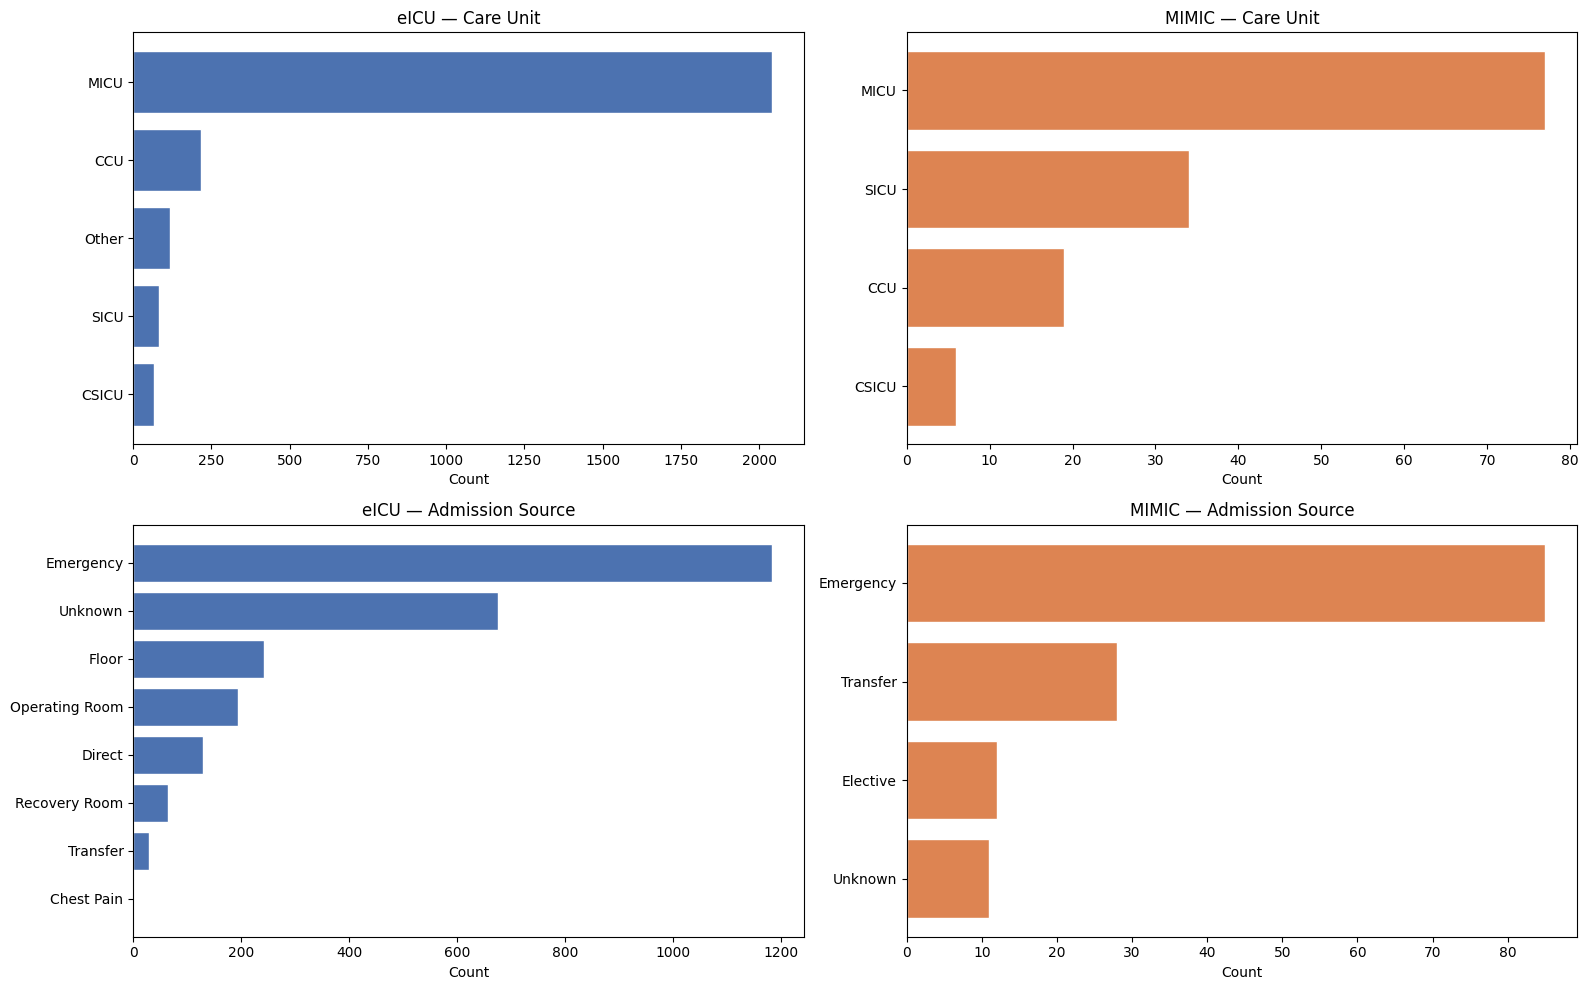

In [19]:
# Care unit and admission source
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row, (col_name, col_label) in enumerate([('careunit', 'Care Unit'), ('admit_source', 'Admission Source')]):
    for col_idx, (df, name, color) in enumerate([
        (df_eicu, 'eICU', PALETTE['eICU']), (df_mimic, 'MIMIC', PALETTE['MIMIC'])
    ]):
        ax = axes[row][col_idx]
        if col_name in df.columns:
            vc = df[col_name].dropna().value_counts().head(10)
            bars = ax.barh(vc.index[::-1], vc.values[::-1], color=color, edgecolor='white')
            ax.set_title(f'{name} — {col_label}')
            ax.set_xlabel('Count')

plt.tight_layout()
plt.show()

---
# 7. Lab Values — Distributions & Outliers

In [20]:
LAB_COLS = [
    'albumin_max', 'bicarbonate_max', 'bun_max', 'creatinine_max',
    'glucose_max', 'hematocrit_max', 'hemoglobin_max', 'inr_max',
    'lactate_max', 'platelets_max', 'potassium_max', 'sodium_max',
    'wbc_max', 'alt_max'
]
LAB_COLS = [c for c in LAB_COLS if c in df_eicu.columns]
print(f'Lab columns for analysis: {LAB_COLS}')

Lab columns for analysis: ['albumin_max', 'bicarbonate_max', 'bun_max', 'creatinine_max', 'glucose_max', 'hematocrit_max', 'hemoglobin_max', 'inr_max', 'lactate_max', 'platelets_max', 'potassium_max', 'sodium_max', 'wbc_max', 'alt_max']


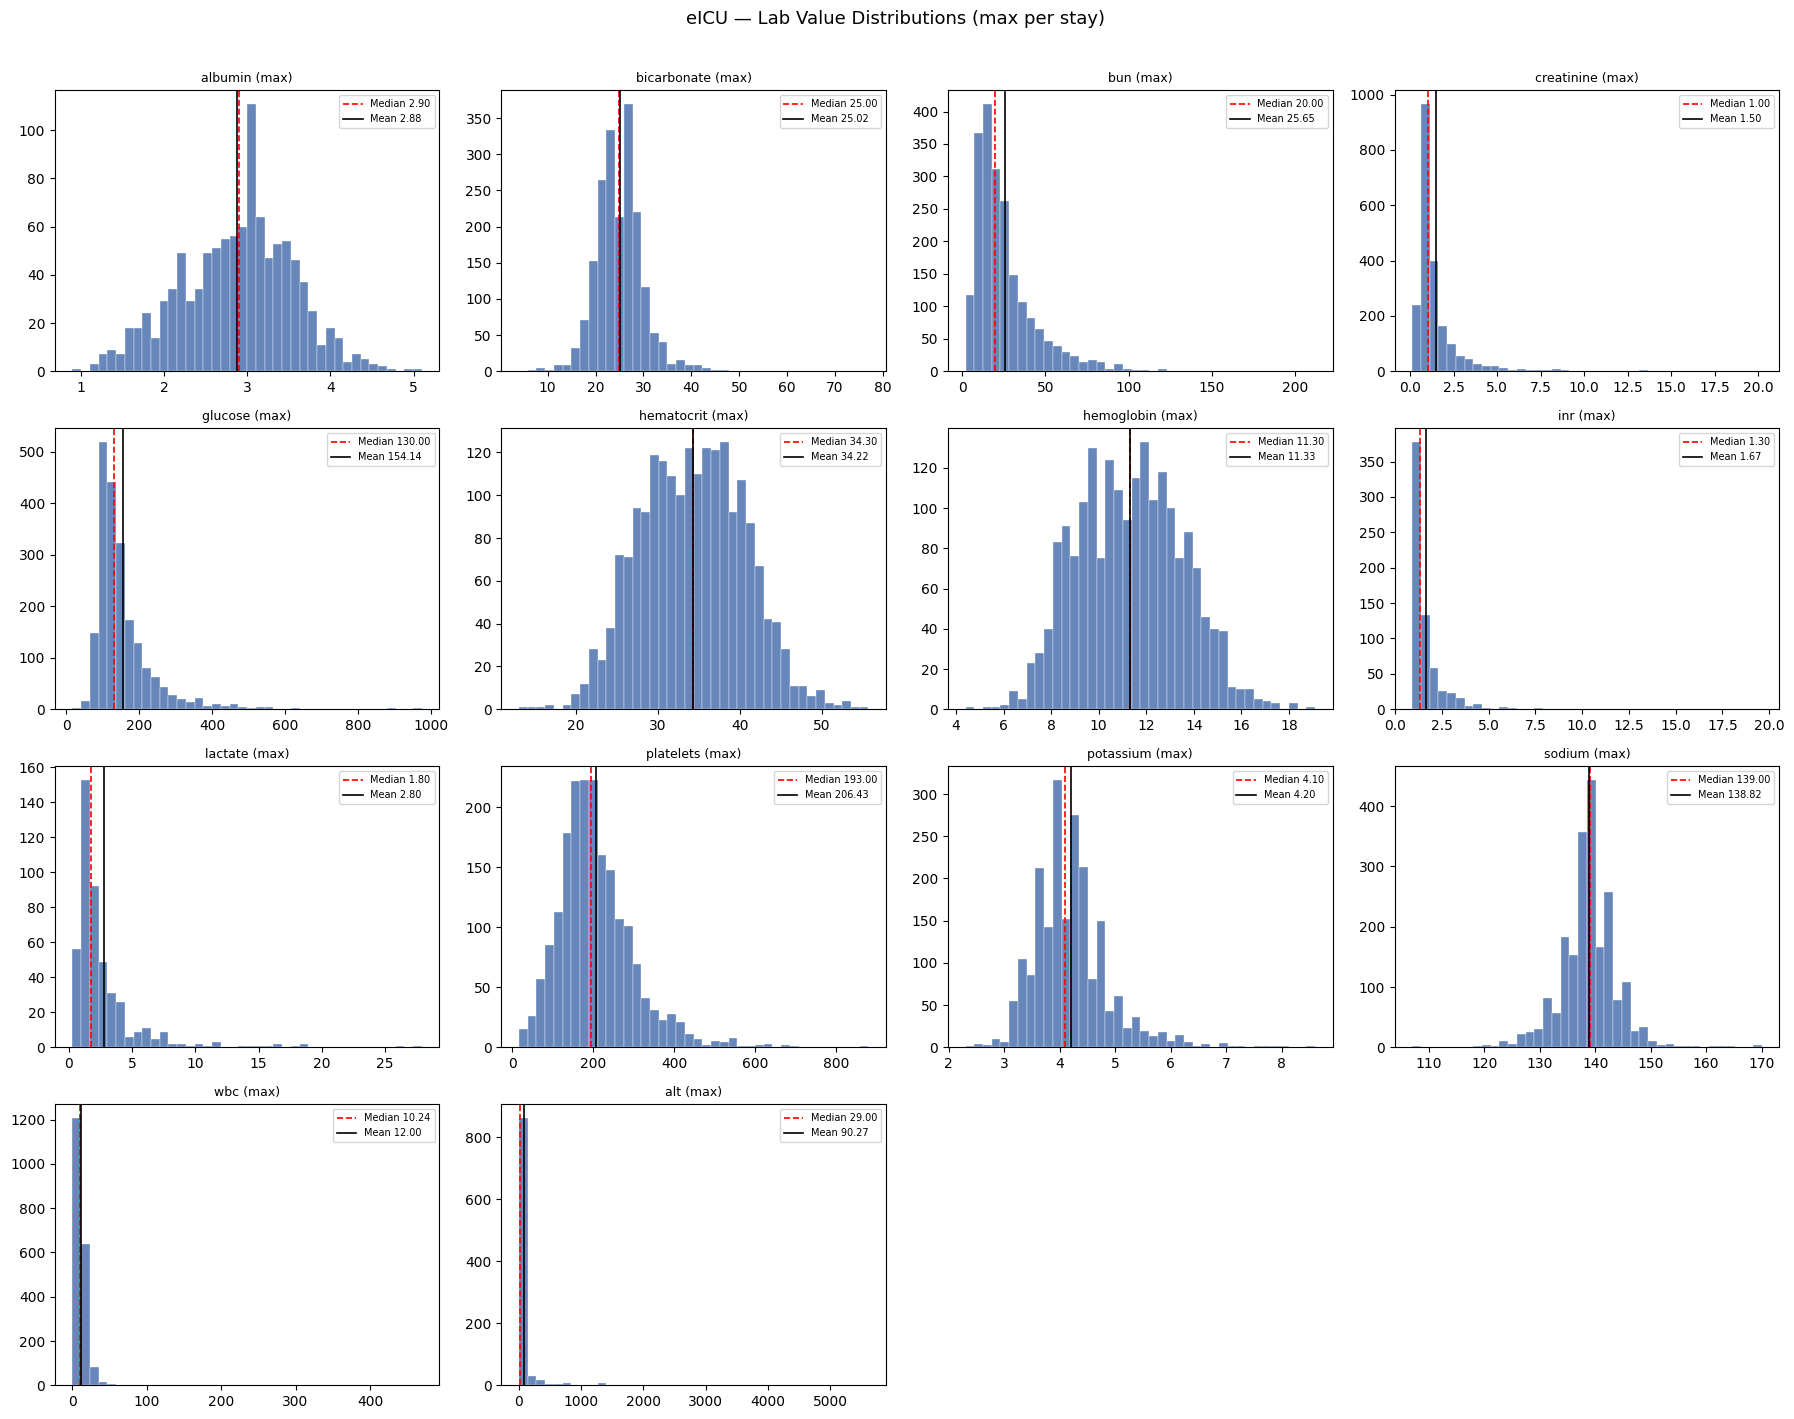

In [21]:
# Distribution histograms for each lab (eICU)
n_cols = 4
n_rows = int(np.ceil(len(LAB_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(LAB_COLS):
    vals = pd.to_numeric(df_eicu[col], errors='coerce').dropna()
    ax = axes[i]
    ax.hist(vals, bins=40, color=PALETTE['eICU'], edgecolor='white', linewidth=0.3, alpha=0.85)
    ax.axvline(vals.median(), color='red',   linestyle='--', linewidth=1.2, label=f'Median {vals.median():.2f}')
    ax.axvline(vals.mean(),   color='black', linestyle='-',  linewidth=1.2, label=f'Mean {vals.mean():.2f}')
    ax.set_title(col.replace('_max', ' (max)'), fontsize=9)
    ax.legend(fontsize=7)
    ax.set_xlabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('eICU — Lab Value Distributions (max per stay)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [22]:
# IQR-based outlier summary for lab values
print('IQR-based outlier counts (eICU lab columns):')
print(f'{"Feature":<25} {"N valid":>8} {"Outliers":>10} {"Outlier %":>10} {"Q1":>8} {"Q3":>8} {"IQR":>8}')
print('-' * 80)

for col in LAB_COLS:
    vals = pd.to_numeric(df_eicu[col], errors='coerce').dropna()
    if len(vals) == 0:
        continue
    q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
    iqr = q3 - q1
    out = ((vals < q1 - 1.5*iqr) | (vals > q3 + 1.5*iqr)).sum()
    print(f'{col:<25} {len(vals):>8,} {out:>10,} {out/len(vals)*100:>9.1f}% {q1:>8.2f} {q3:>8.2f} {iqr:>8.2f}')

IQR-based outlier counts (eICU lab columns):
Feature                    N valid   Outliers  Outlier %       Q1       Q3      IQR
--------------------------------------------------------------------------------
albumin_max                  1,051          1       0.1%     2.40     3.40     1.00
bicarbonate_max              1,944         93       4.8%    22.00    27.00     5.00
bun_max                      2,089        129       6.2%    13.00    32.00    19.00
creatinine_max               2,092        211      10.1%     0.77     1.56     0.79
glucose_max                  2,075        139       6.7%   104.00   174.00    70.00
hematocrit_max               2,000          7       0.4%    29.60    38.80     9.20
hemoglobin_max               1,970          5       0.3%     9.60    12.90     3.30
inr_max                        659         71      10.8%     1.10     1.71     0.61
lactate_max                    469         47      10.0%     1.20     3.10     1.90
platelets_max                1,920

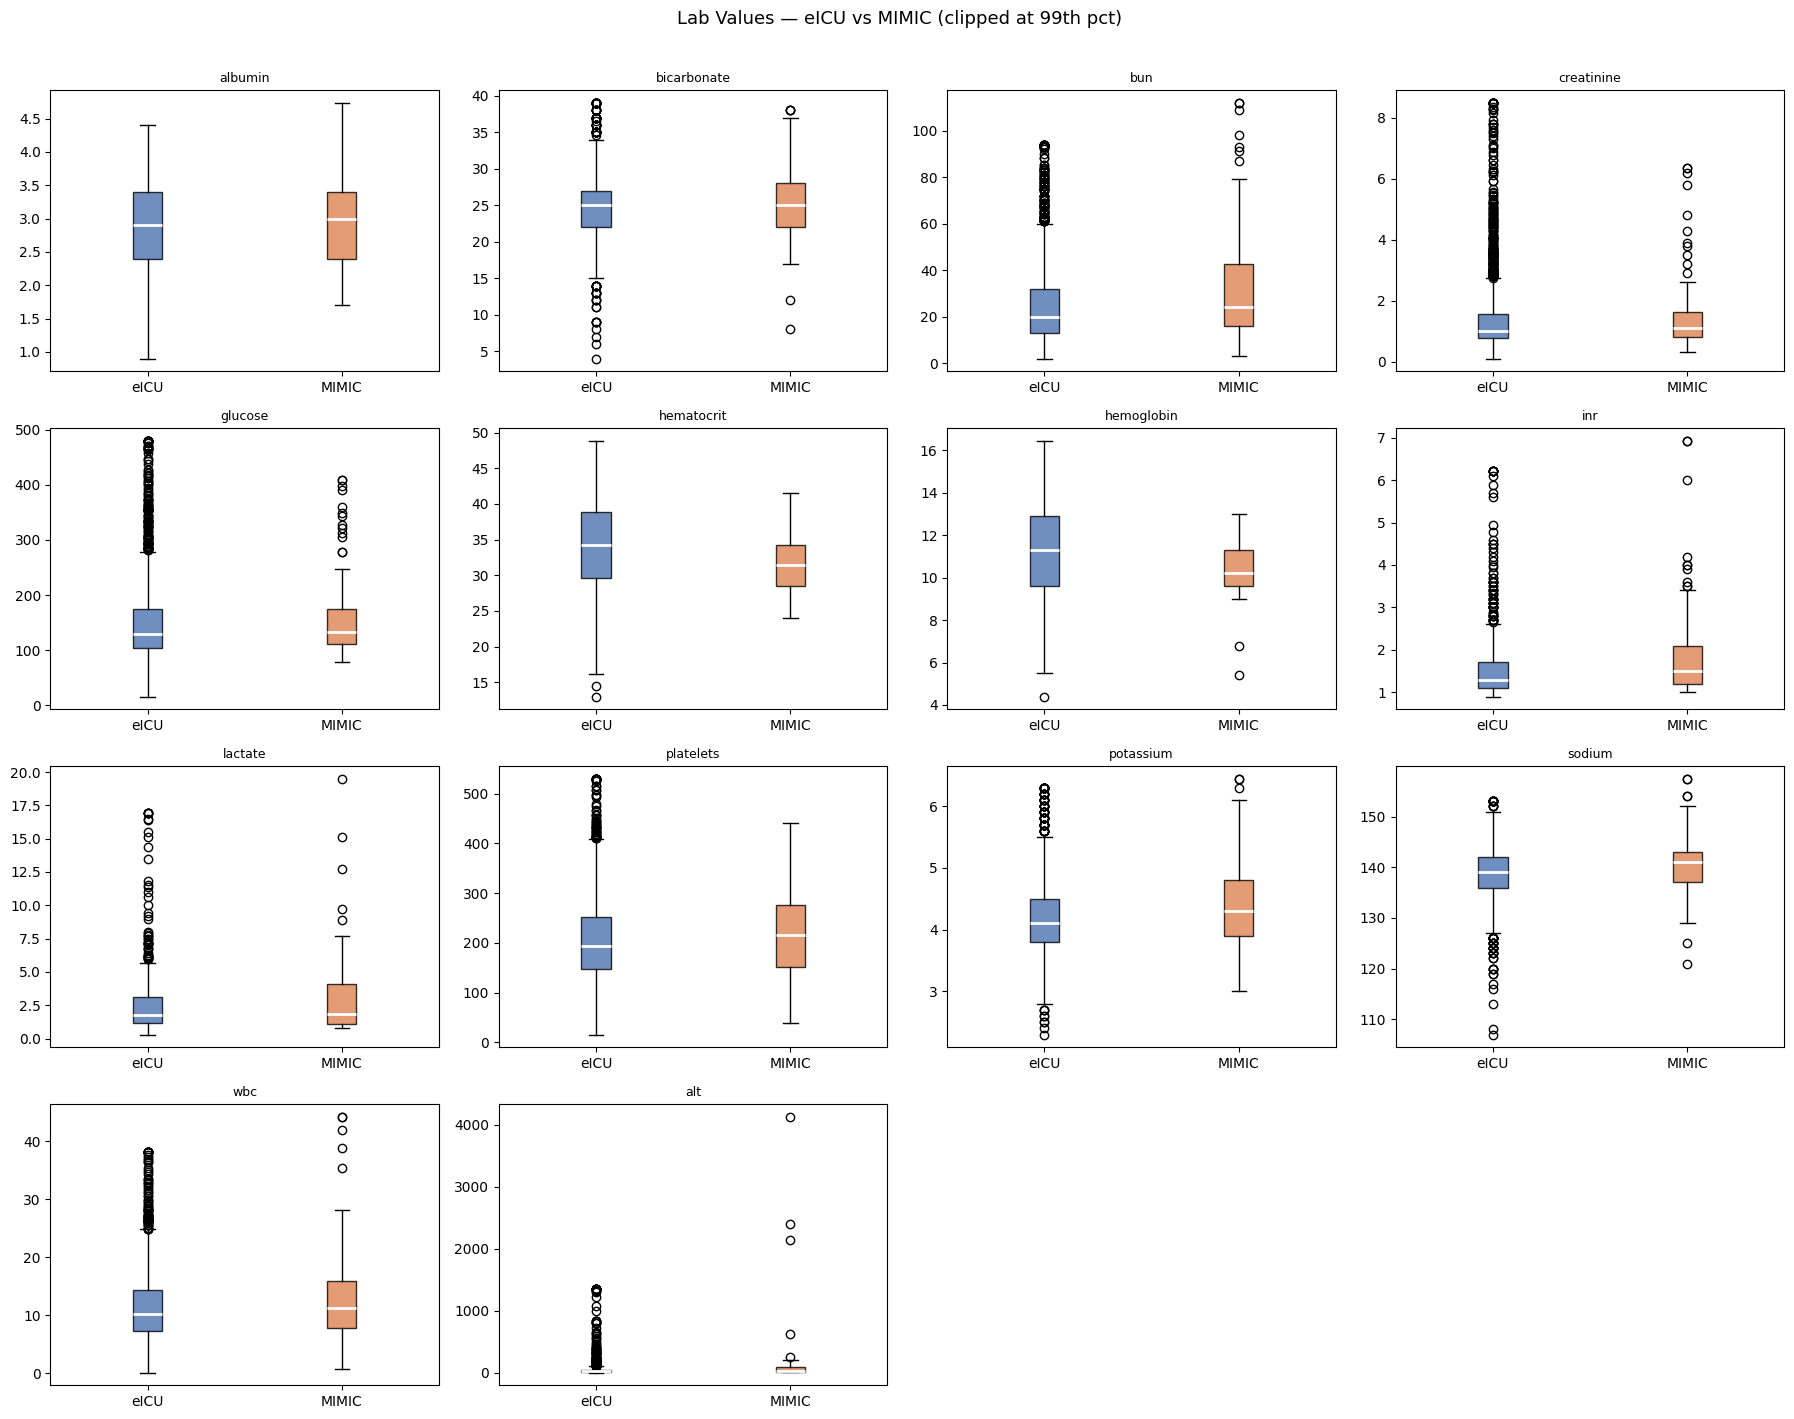

In [23]:
# Box plots — clipped at 99th pct for readability
n_rows = int(np.ceil(len(LAB_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(LAB_COLS):
    vals_e = pd.to_numeric(df_eicu[col], errors='coerce').dropna()
    vals_m = pd.to_numeric(df_mimic_aligned[col], errors='coerce').dropna() if col in df_mimic_aligned.columns else pd.Series(dtype=float)

    data, labels, colors = [], [], []
    if len(vals_e) > 0:
        cap = vals_e.quantile(0.99)
        data.append(vals_e.clip(upper=cap))
        labels.append('eICU')
        colors.append(PALETTE['eICU'])
    if len(vals_m) > 0:
        cap = vals_m.quantile(0.99)
        data.append(vals_m.clip(upper=cap))
        labels.append('MIMIC')
        colors.append(PALETTE['MIMIC'])

    ax = axes[i]
    bp = ax.boxplot(data, patch_artist=True, labels=labels,
                    medianprops={'color': 'white', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_title(col.replace('_max', ''), fontsize=9)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Lab Values — eICU vs MIMIC (clipped at 99th pct)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
# 8. Vital Signs — Distributions

In [24]:
# Use harmonised column names (eICU naming convention after rename)
VITAL_GROUPS = {
    'Heart Rate'        : ['heartrate_min', 'heartrate_mean', 'heartrate_max'],
    'Respiration Rate'  : ['respiration_min', 'respiration_mean', 'respiration_max'],
    'SpO2'              : ['sao2_min', 'sao2_mean', 'sao2_max'],
    'Temperature'       : ['temp_min', 'temp_mean', 'temp_max'],
    'Systolic BP'       : ['ssystolic_min', 'ssystolic_mean', 'ssystolic_max'],
    'Diastolic BP'      : ['sdiastolic_min', 'sdiastolic_mean', 'sdiastolic_max'],
    'Mean Arterial Pres': ['systemicmean_min', 'systemicmean_mean', 'systemicmean_max'],
}

# Filter to groups where the columns exist in both aligned datasets
VITAL_GROUPS_VALID = {}
for group, cols in VITAL_GROUPS.items():
    valid = [c for c in cols if c in df_eicu.columns and c in df_mimic_aligned.columns]
    if valid:
        VITAL_GROUPS_VALID[group] = valid

print('Valid vital sign groups:')
for g, cols in VITAL_GROUPS_VALID.items():
    print(f'  {g}: {cols}')

Valid vital sign groups:
  Heart Rate: ['heartrate_min', 'heartrate_mean', 'heartrate_max']
  Respiration Rate: ['respiration_min', 'respiration_mean', 'respiration_max']
  SpO2: ['sao2_min', 'sao2_mean', 'sao2_max']
  Temperature: ['temp_min', 'temp_mean', 'temp_max']
  Systolic BP: ['ssystolic_min', 'ssystolic_mean', 'ssystolic_max']
  Diastolic BP: ['sdiastolic_min', 'sdiastolic_mean', 'sdiastolic_max']
  Mean Arterial Pres: ['systemicmean_min', 'systemicmean_mean', 'systemicmean_max']


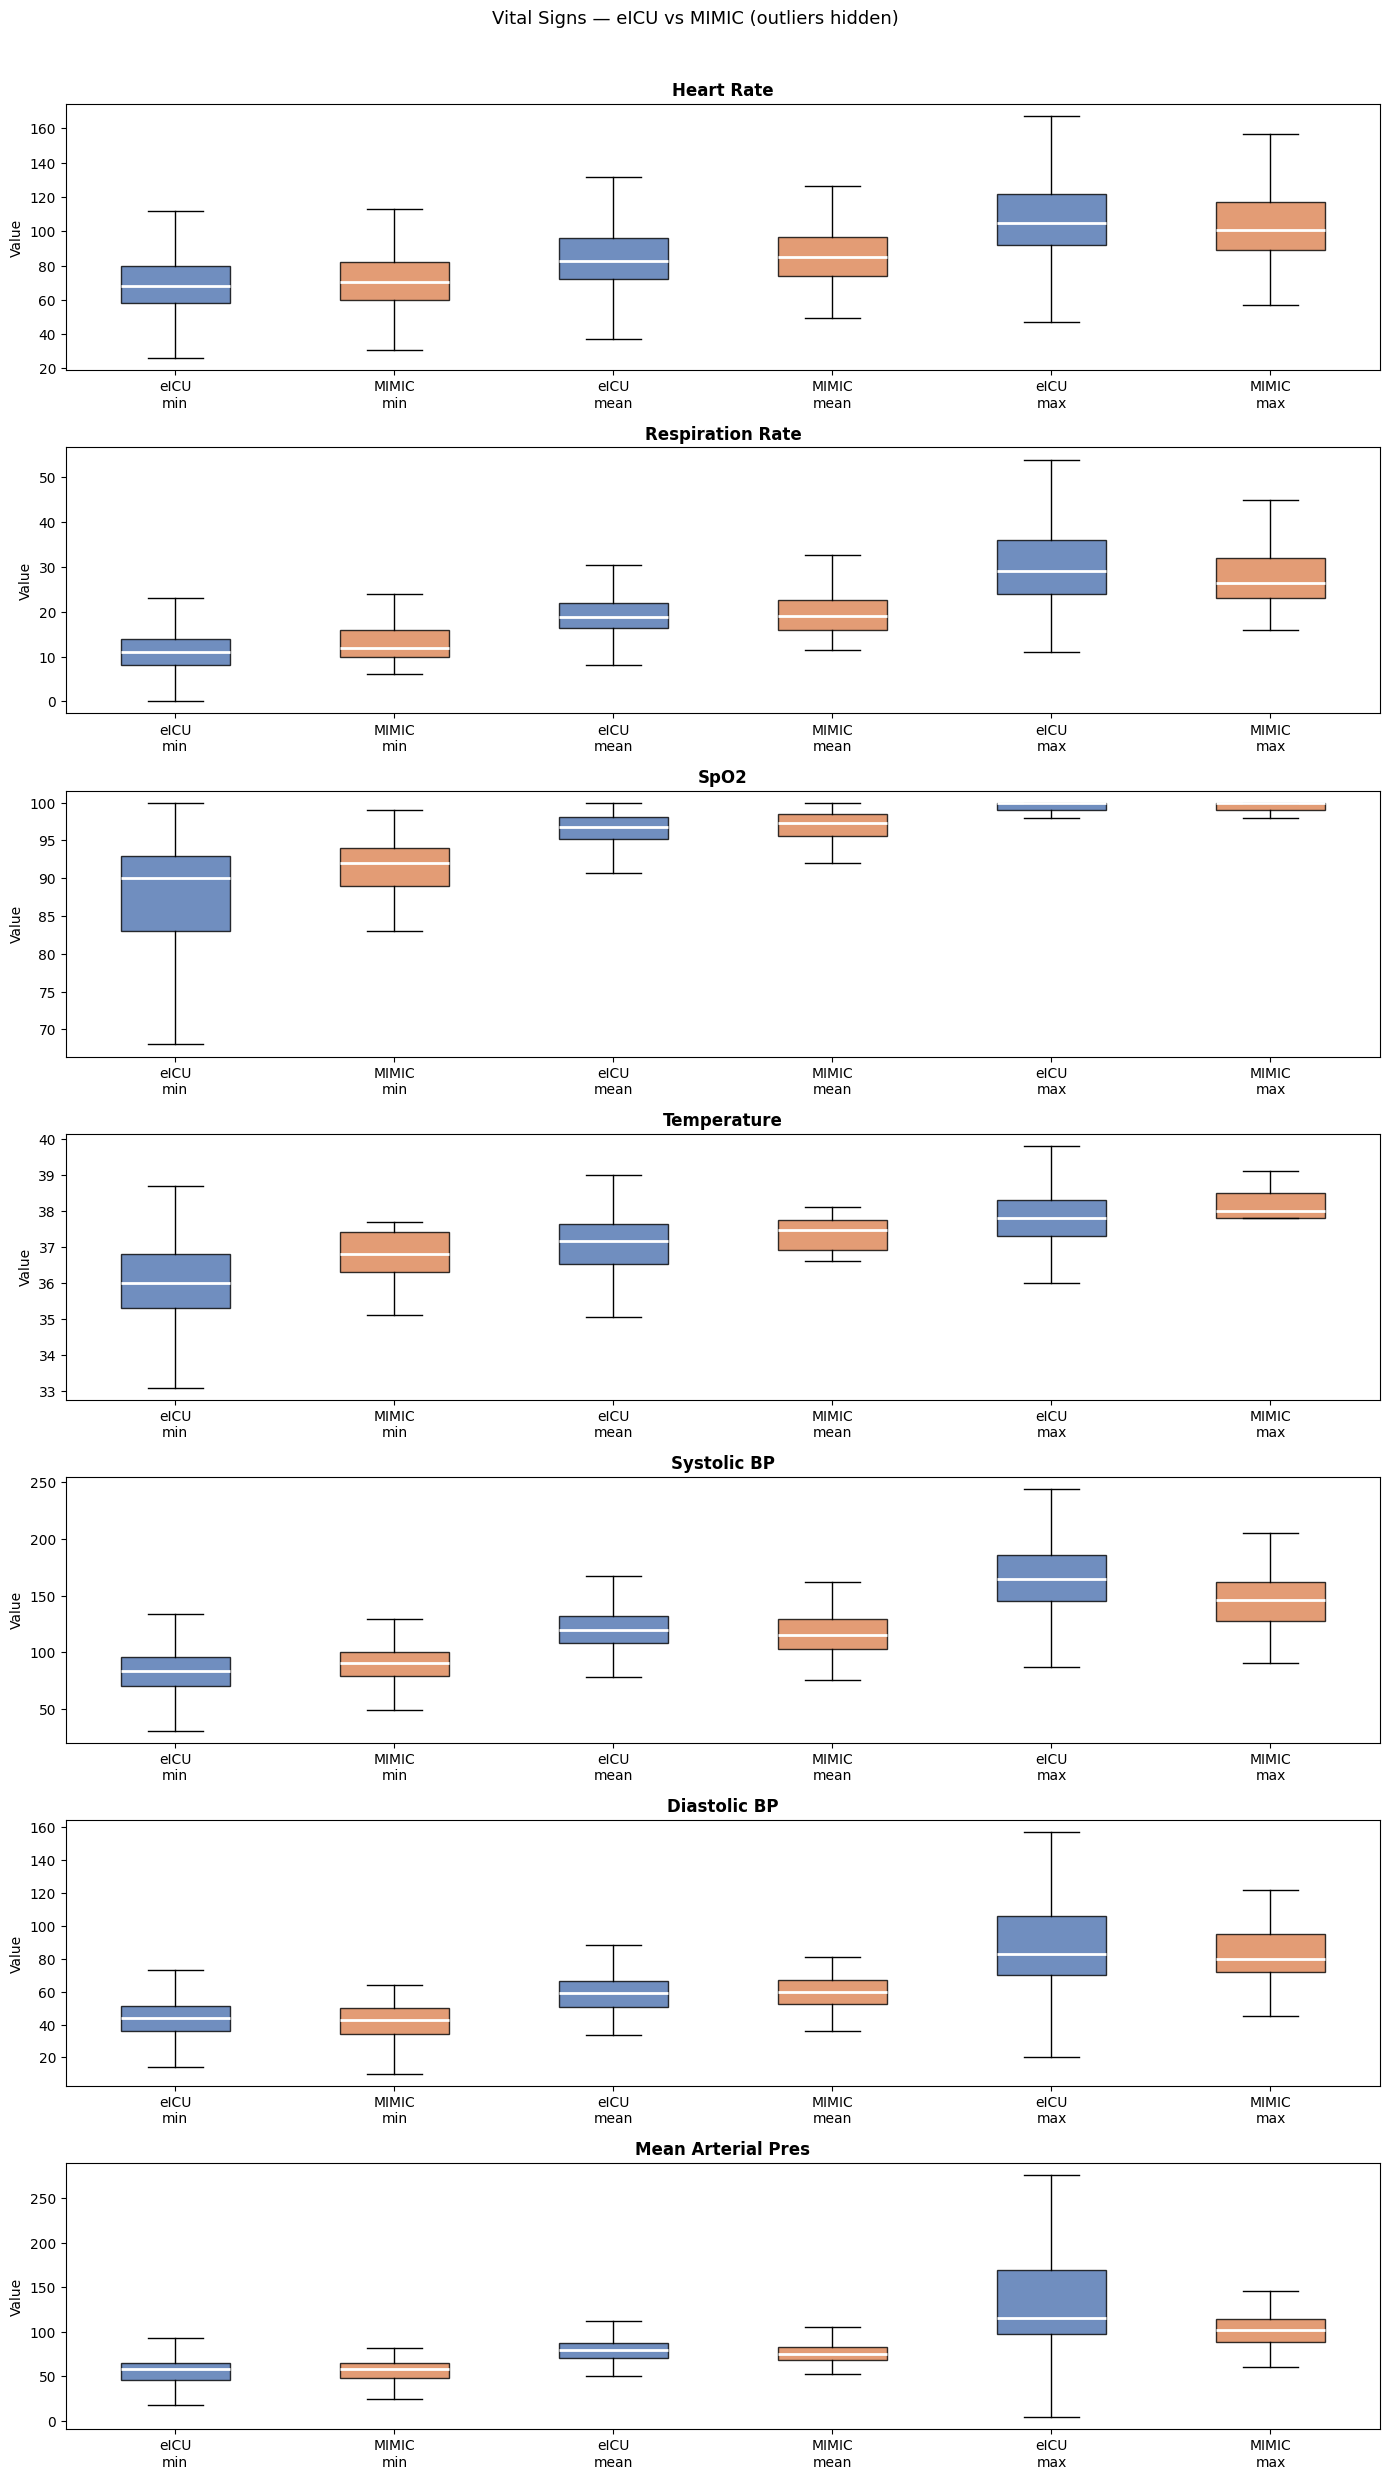

In [25]:
# Box plots: min/mean/max for each vital group — eICU vs MIMIC
n_groups = len(VITAL_GROUPS_VALID)
fig, axes = plt.subplots(n_groups, 1, figsize=(14, n_groups * 3.5))
if n_groups == 1:
    axes = [axes]

for ax, (group_name, cols) in zip(axes, VITAL_GROUPS_VALID.items()):
    data, tick_labels, colors = [], [], []
    for col in cols:
        vals_e = pd.to_numeric(df_eicu[col], errors='coerce').dropna()
        vals_m = pd.to_numeric(df_mimic_aligned[col], errors='coerce').dropna()
        suffix = col.split('_')[-1]  # min / mean / max
        if len(vals_e):
            data.append(vals_e)
            tick_labels.append(f'eICU\n{suffix}')
            colors.append(PALETTE['eICU'])
        if len(vals_m):
            data.append(vals_m)
            tick_labels.append(f'MIMIC\n{suffix}')
            colors.append(PALETTE['MIMIC'])

    bp = ax.boxplot(data, patch_artist=True, labels=tick_labels,
                    medianprops={'color': 'white', 'linewidth': 2}, showfliers=False)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_title(group_name, fontweight='bold')
    ax.set_ylabel('Value')

plt.suptitle('Vital Signs — eICU vs MIMIC (outliers hidden)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
# 9. Bivariate Analysis — Feature vs Mortality

For each key clinical variable: compare distributions between survivors and non-survivors in eICU.

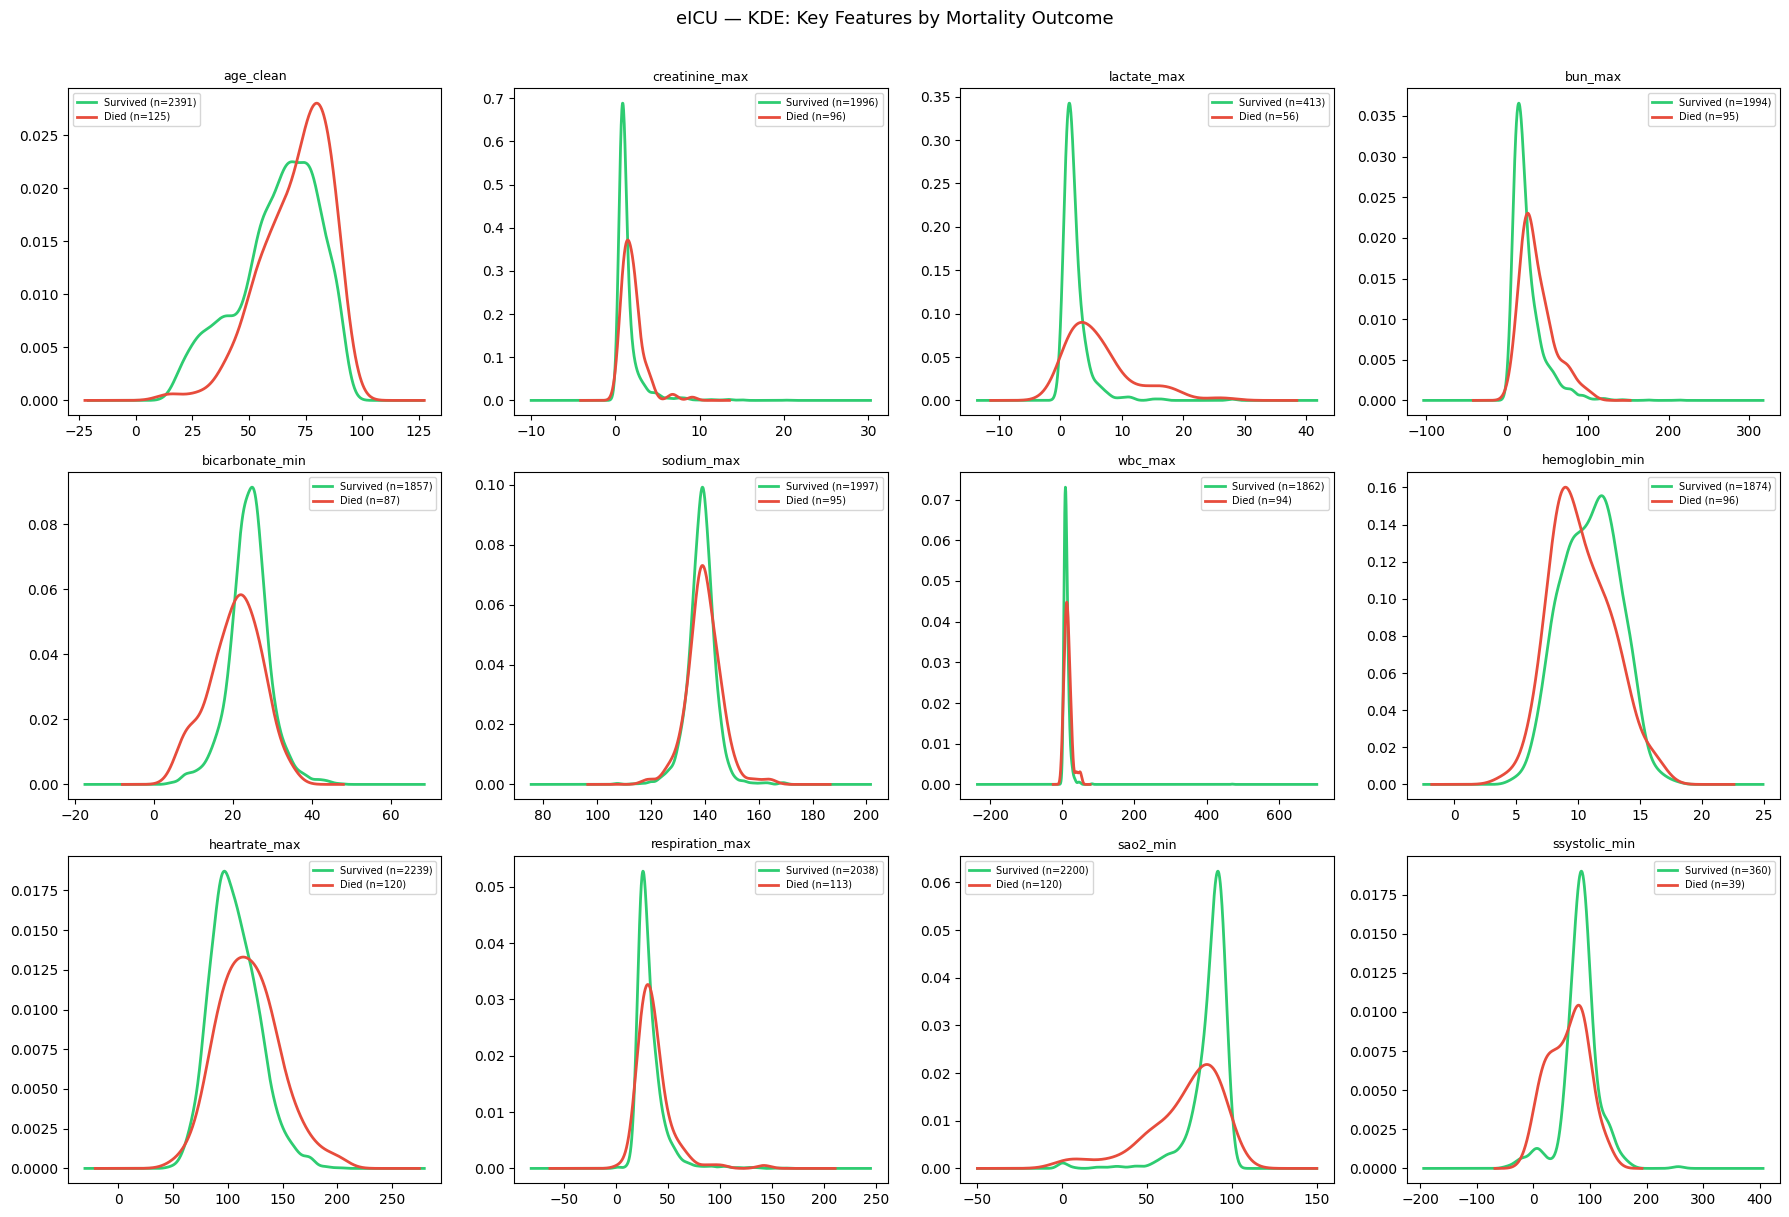

In [26]:
df_eicu['mortality_num'] = pd.to_numeric(df_eicu['mortality'], errors='coerce').astype('Int64')

KEY_FEATURES = [
    'age_clean', 'creatinine_max', 'lactate_max', 'bun_max',
    'bicarbonate_min', 'sodium_max', 'wbc_max', 'hemoglobin_min',
    'heartrate_max', 'respiration_max', 'sao2_min', 'ssystolic_min'
]
KEY_FEATURES = [c for c in KEY_FEATURES if c in df_eicu.columns]

n_cols = 4
n_rows = int(np.ceil(len(KEY_FEATURES) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(KEY_FEATURES):
    ax = axes[i]
    df_plot = df_eicu[[col, 'mortality_num']].copy()
    df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')
    df_plot = df_plot.dropna()

    for mort_val, label, color in [(0, 'Survived', MORT_PALETTE[0]), (1, 'Died', MORT_PALETTE[1])]:
        vals = df_plot.loc[df_plot['mortality_num'] == mort_val, col]
        vals.plot.kde(ax=ax, color=color, label=f'{label} (n={len(vals)})', linewidth=2)

    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)
    ax.set_xlabel('')
    ax.set_ylabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('eICU — KDE: Key Features by Mortality Outcome', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

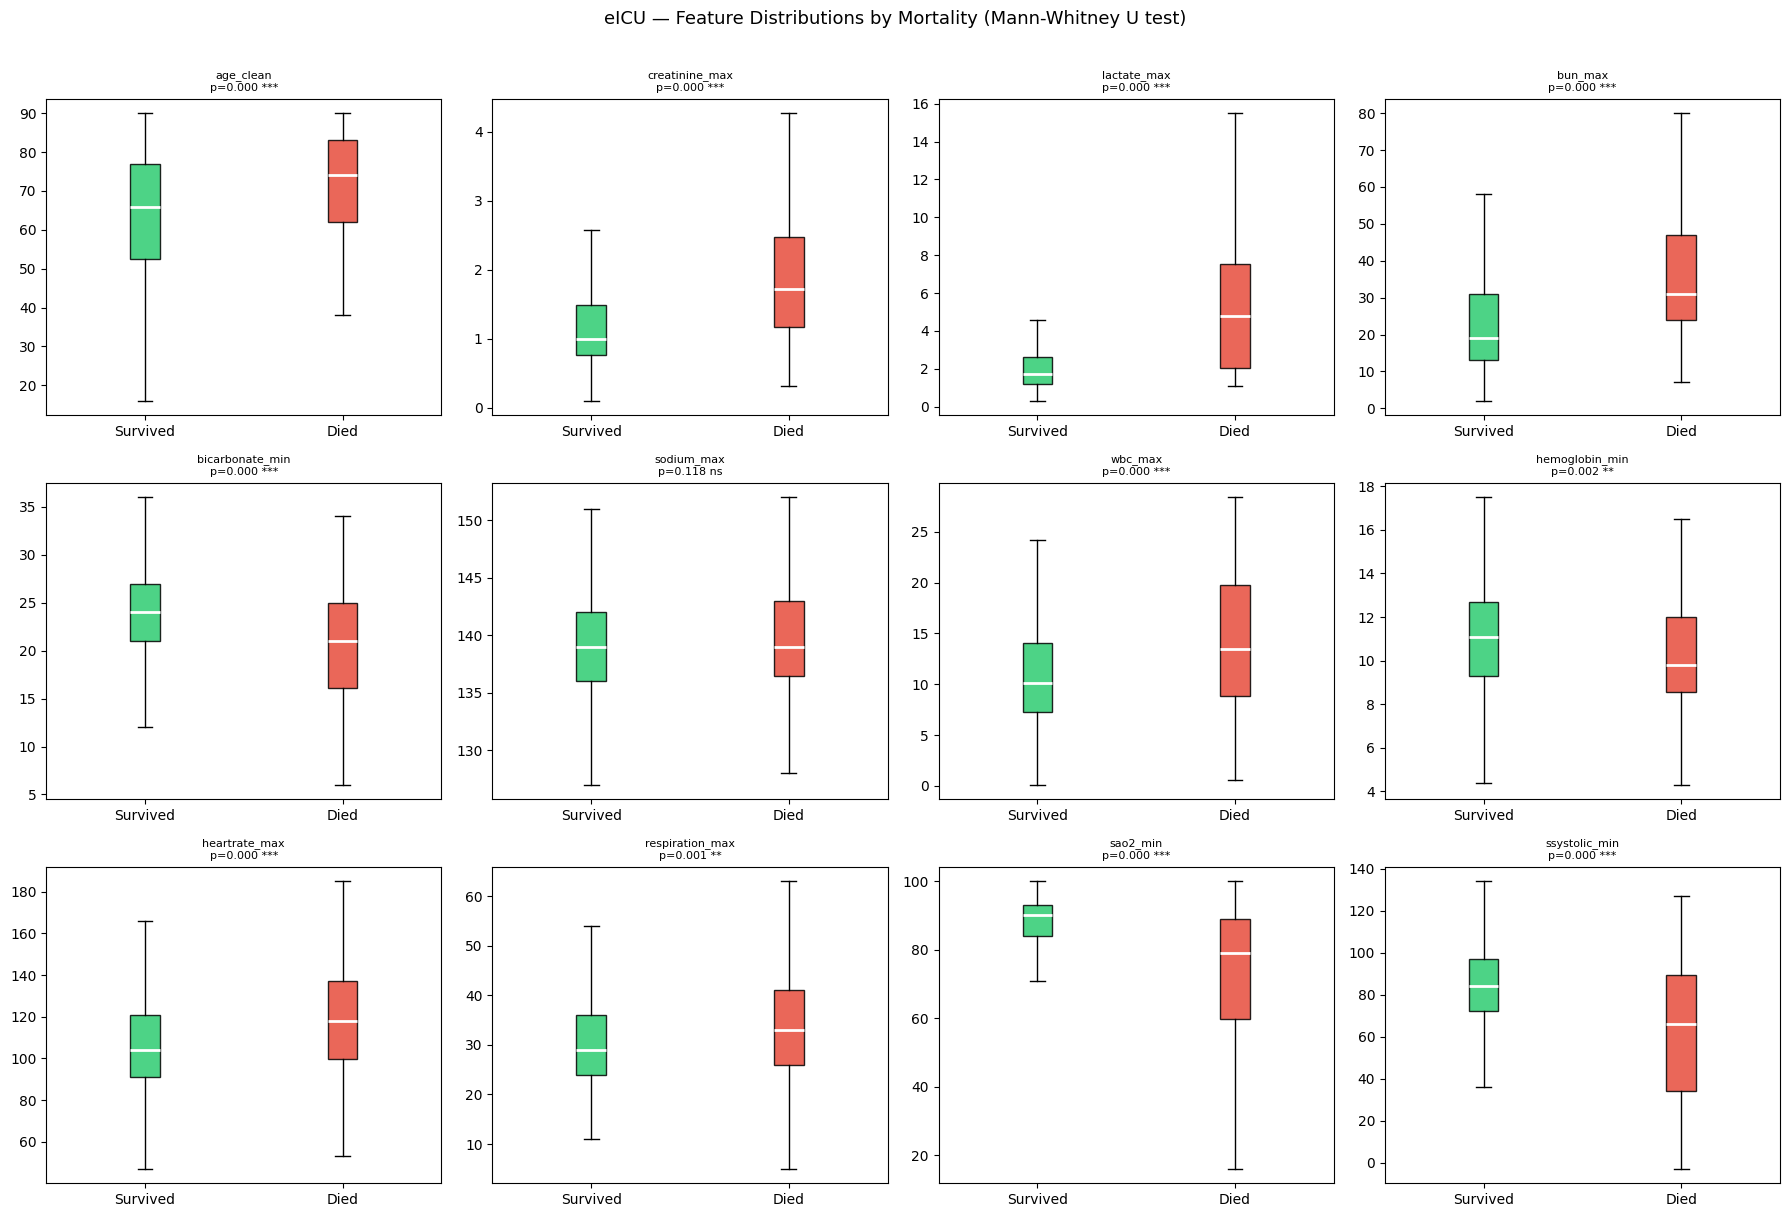

In [27]:
# Box plots with statistical significance (Mann-Whitney U)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(KEY_FEATURES):
    ax = axes[i]
    df_plot = df_eicu[[col, 'mortality_num']].copy()
    df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')
    df_plot = df_plot.dropna()

    g0 = df_plot.loc[df_plot['mortality_num'] == 0, col]
    g1 = df_plot.loc[df_plot['mortality_num'] == 1, col]

    bp = ax.boxplot([g0, g1], patch_artist=True, labels=['Survived', 'Died'],
                    showfliers=False, medianprops={'color': 'white', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], [MORT_PALETTE[0], MORT_PALETTE[1]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)

    # Mann-Whitney U test
    if len(g0) > 1 and len(g1) > 1:
        _, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        ax.set_title(f'{col}\np={p:.3f} {sig}', fontsize=8)
    else:
        ax.set_title(col, fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('eICU — Feature Distributions by Mortality (Mann-Whitney U test)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

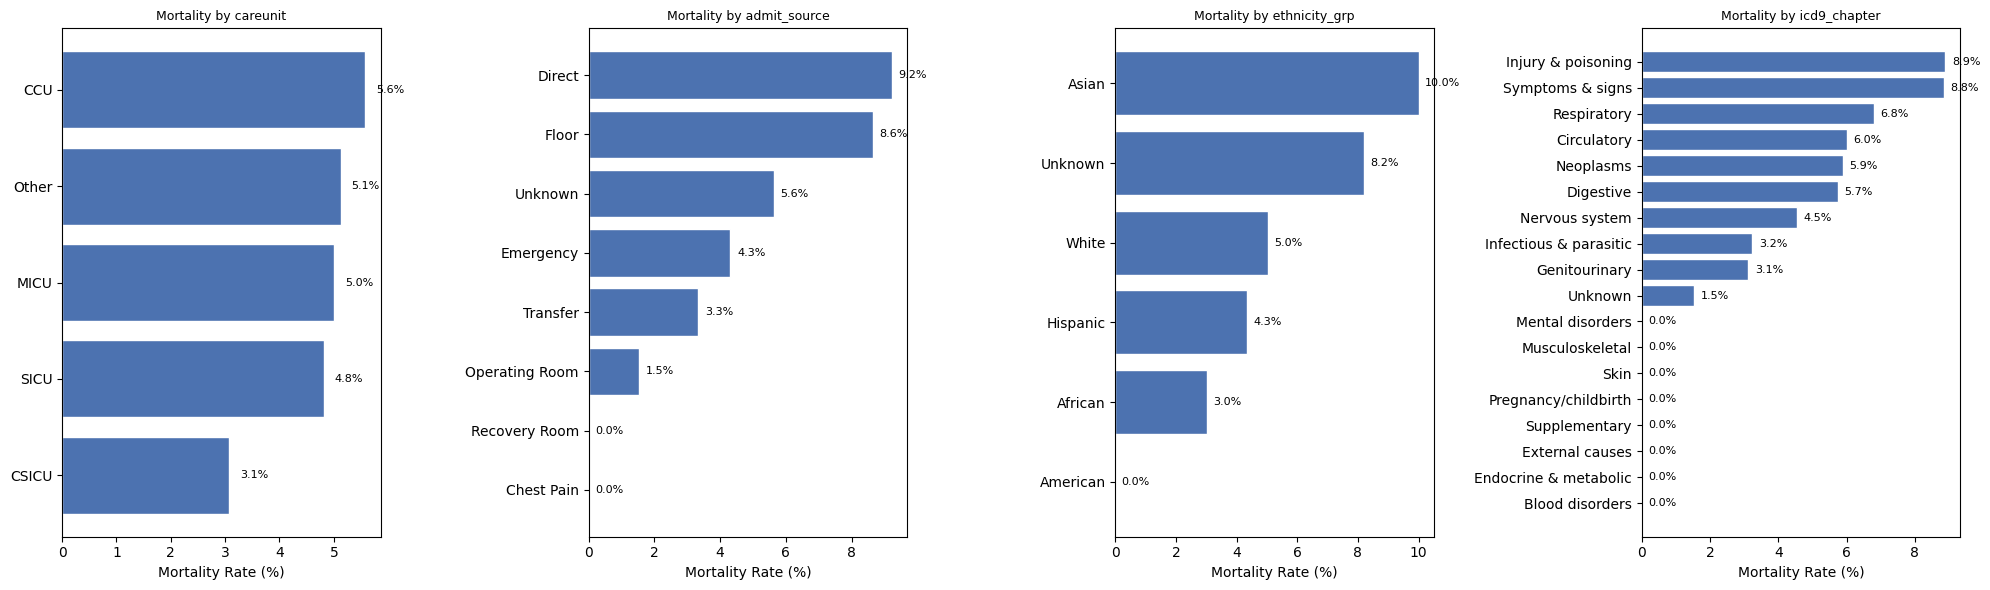

In [28]:
# Categorical features: mortality rate by group
CAT_FEATURES = ['careunit', 'admit_source', 'ethnicity_grp', 'icd9_chapter']
CAT_FEATURES = [c for c in CAT_FEATURES if c in df_eicu.columns]

fig, axes = plt.subplots(1, len(CAT_FEATURES), figsize=(20, 6))

for ax, col in zip(axes, CAT_FEATURES):
    df_plot = df_eicu[[col, 'mortality_num']].dropna()
    mort_rate = df_plot.groupby(col, observed=True)['mortality_num'].mean() * 100
    mort_rate = mort_rate.sort_values(ascending=True)
    bars = ax.barh(mort_rate.index, mort_rate.values, color=PALETTE['eICU'], edgecolor='white')
    for bar, v in zip(bars, mort_rate.values):
        ax.text(v + 0.2, bar.get_y() + bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=8)
    ax.set_xlabel('Mortality Rate (%)')
    ax.set_title(f'Mortality by {col}', fontsize=9)

plt.tight_layout()
plt.show()

---
# 10. Correlation Analysis

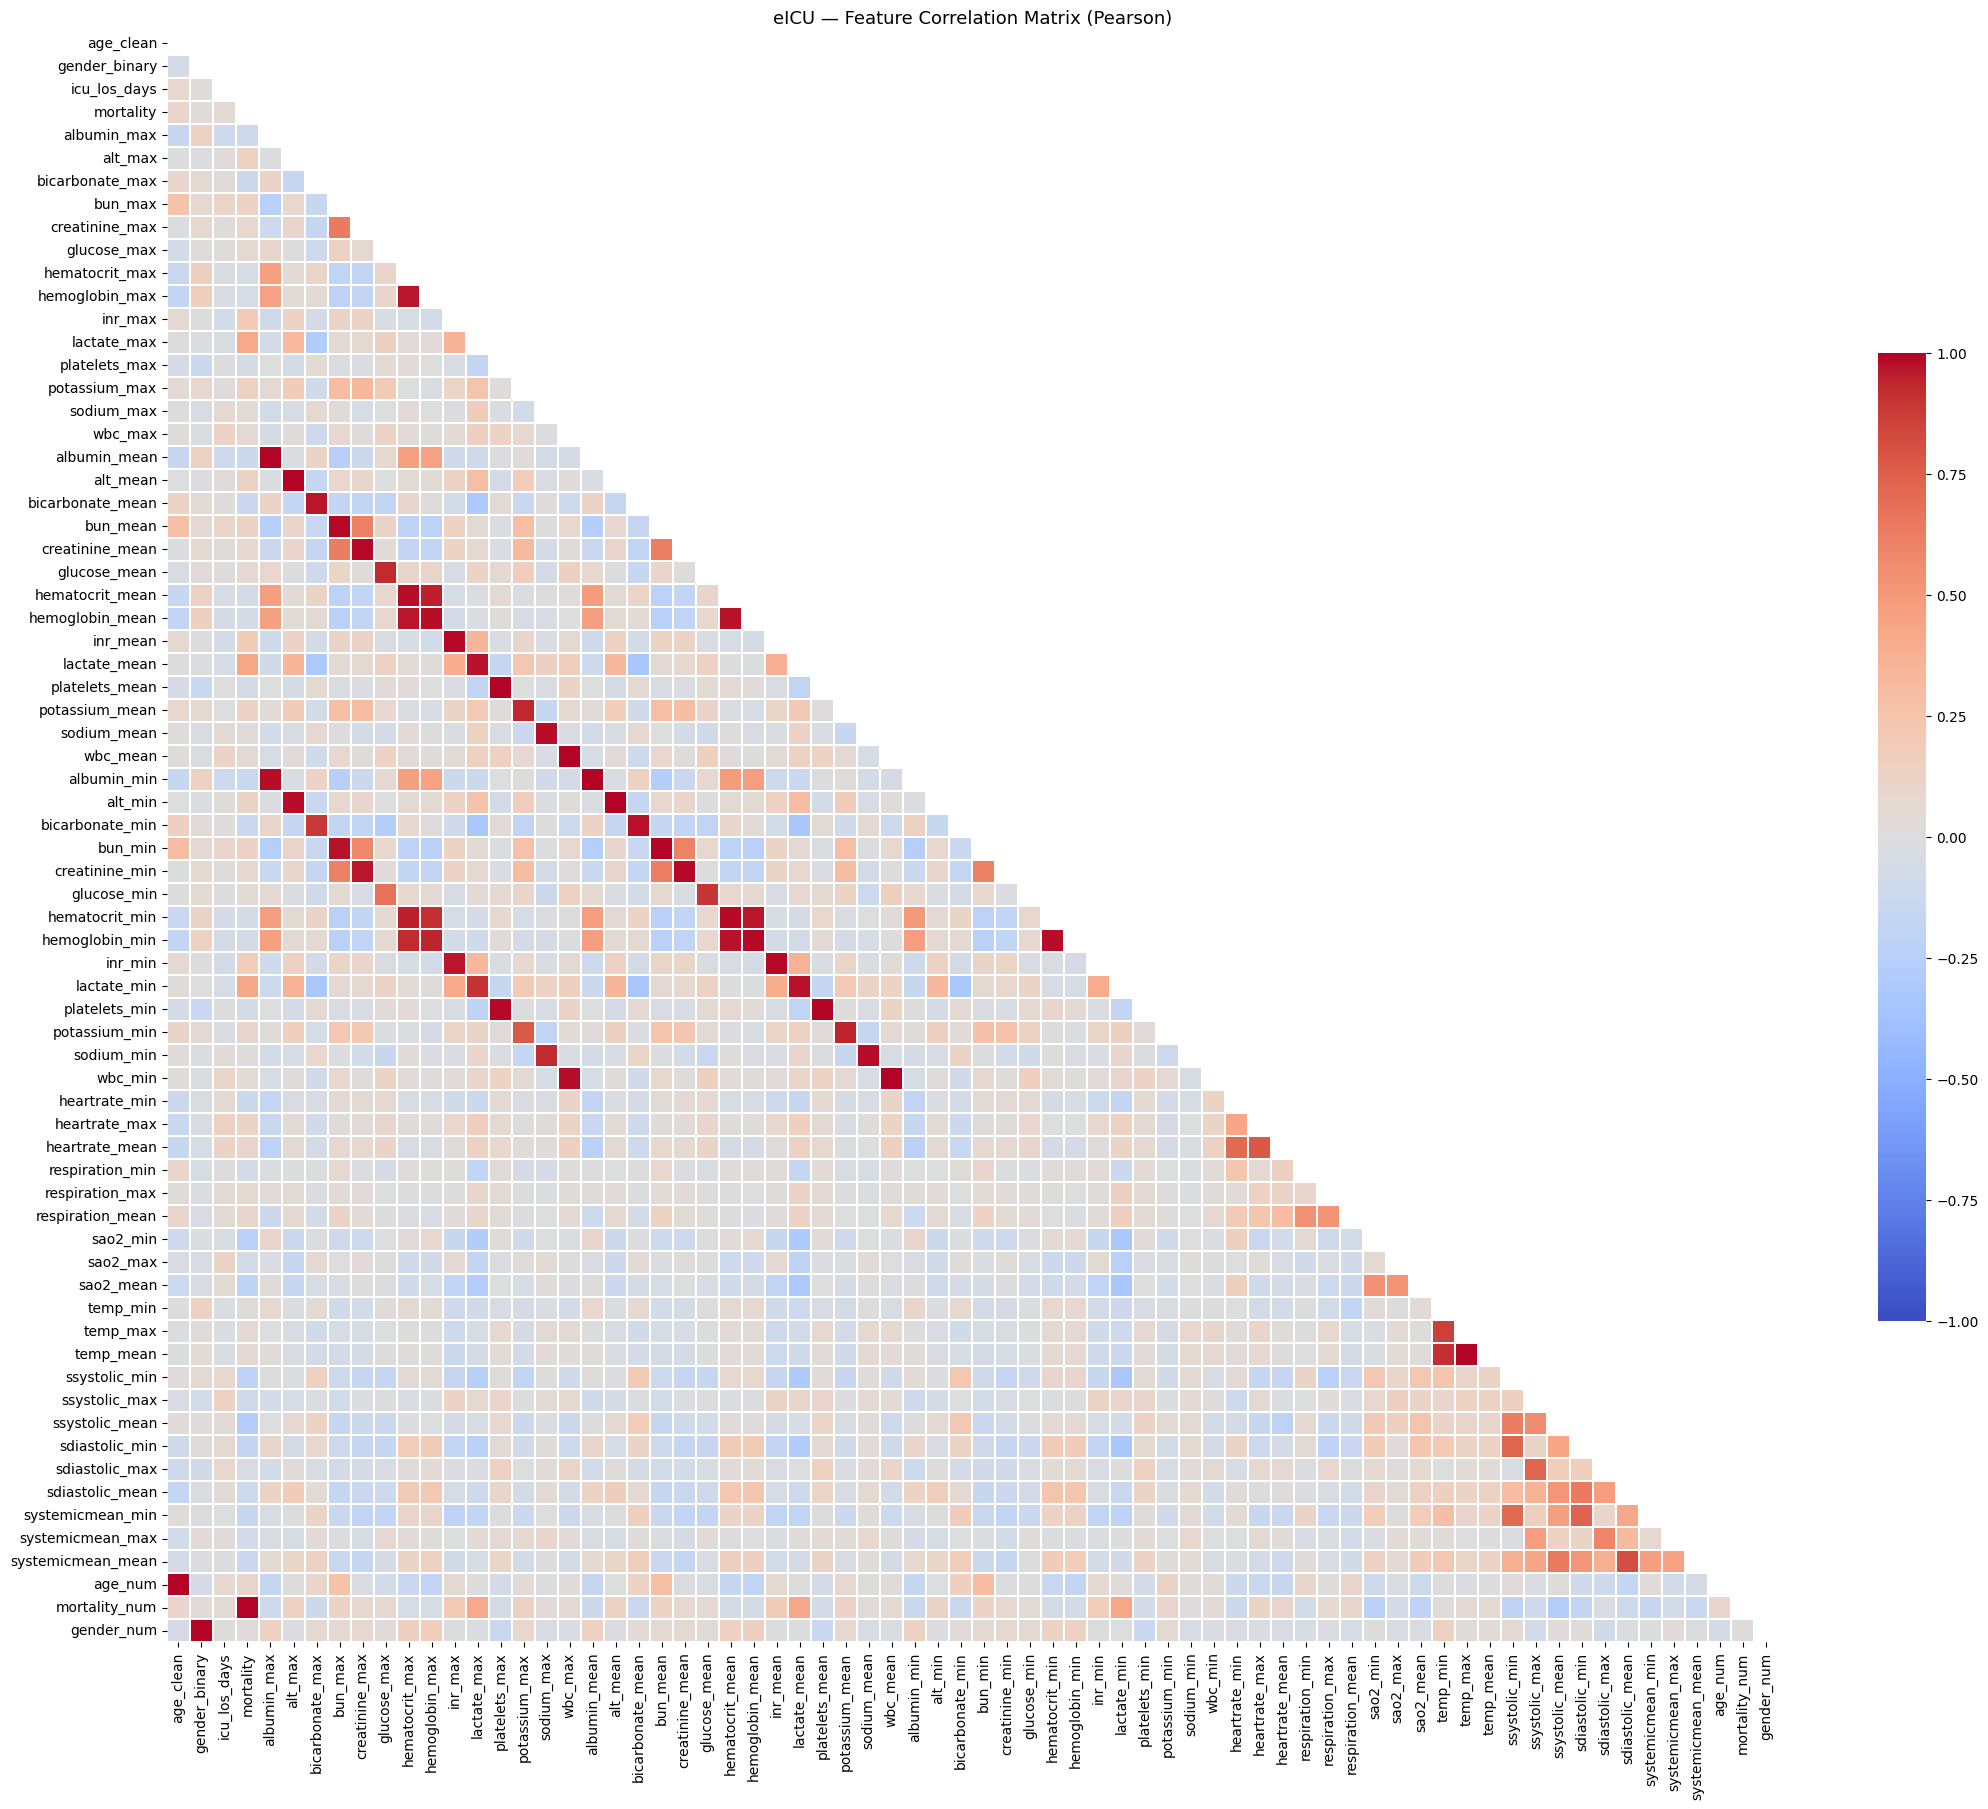

In [29]:
# Select numeric columns (exclude IDs and dataset flag)
EXCLUDE = ['stay_id', 'dataset']
num_cols = [c for c in df_eicu.select_dtypes(include=np.number).columns
            if c not in EXCLUDE]

corr_matrix = df_eicu[num_cols].apply(pd.to_numeric, errors='coerce').corr()

fig, ax = plt.subplots(figsize=(22, 18))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, ax=ax,
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.3, linecolor='white',
    annot=False, square=True, cbar_kws={'shrink': 0.6}
)
ax.set_title('eICU — Feature Correlation Matrix (Pearson)', fontsize=13)
plt.tight_layout()
plt.show()

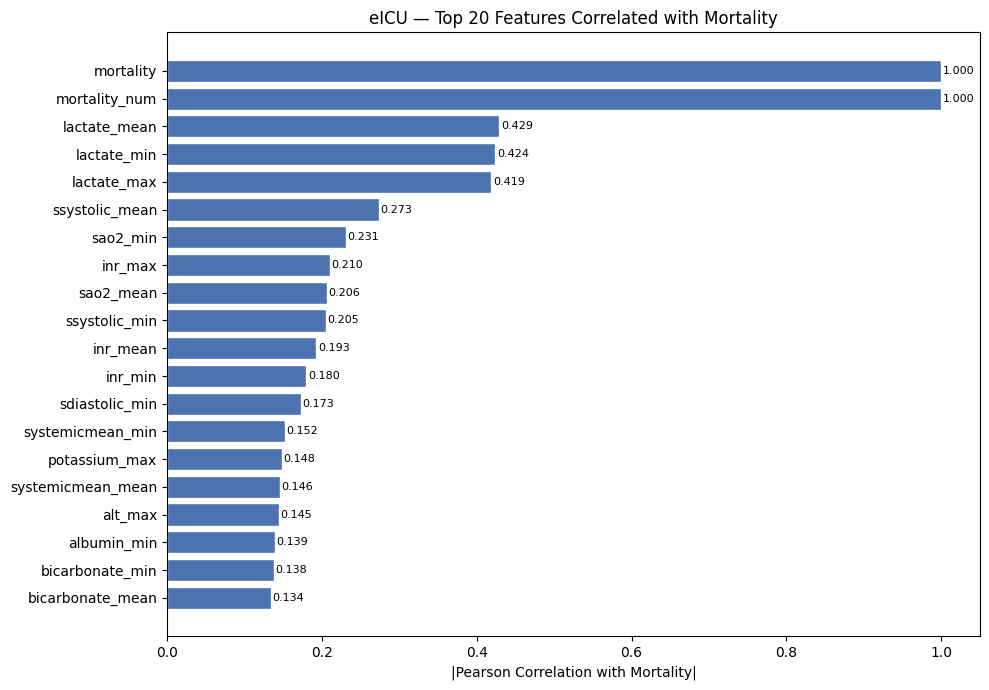

In [30]:
# Top features most correlated with mortality
df_eicu['mortality_float'] = pd.to_numeric(df_eicu['mortality'], errors='coerce')
corr_with_mort = (
    df_eicu[num_cols + ['mortality_float']]
    .apply(pd.to_numeric, errors='coerce')
    .corr()['mortality_float']
    .drop('mortality_float', errors='ignore')
    .dropna()
    .abs()
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(corr_with_mort.index[::-1], corr_with_mort.values[::-1],
               color=PALETTE['eICU'], edgecolor='white')
for bar, v in zip(bars, corr_with_mort.values[::-1]):
    ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', fontsize=8)
ax.set_xlabel('|Pearson Correlation with Mortality|')
ax.set_title('eICU — Top 20 Features Correlated with Mortality')
plt.tight_layout()
plt.show()

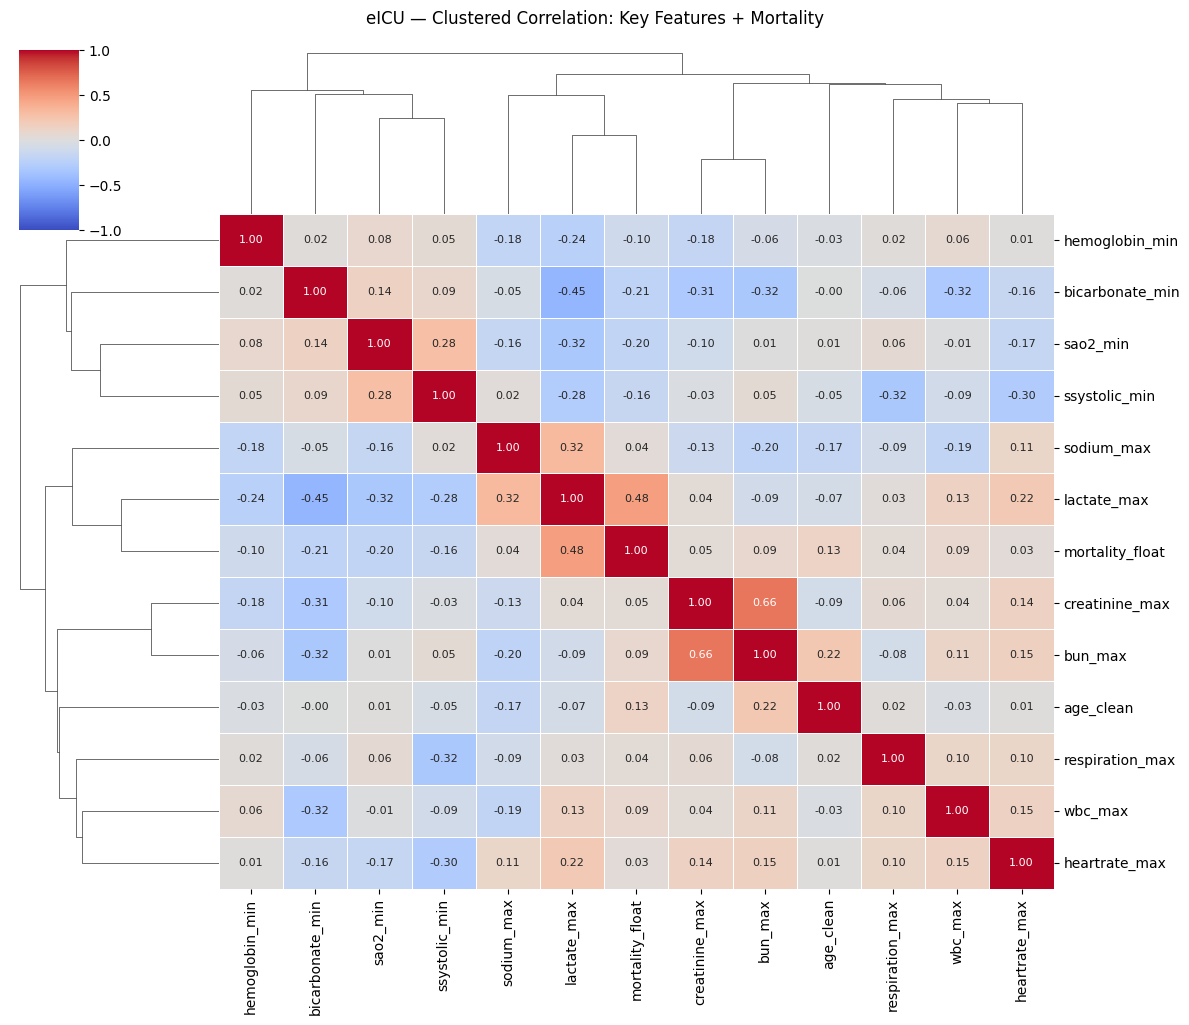

In [31]:
# Clustermap of key clinical features
CLUSTER_COLS = KEY_FEATURES + ['mortality_float']
CLUSTER_COLS = [c for c in CLUSTER_COLS if c in df_eicu.columns]

cluster_df = df_eicu[CLUSTER_COLS].apply(pd.to_numeric, errors='coerce').dropna()

g = sns.clustermap(
    cluster_df.corr(),
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    figsize=(12, 10), linewidths=0.5,
    annot=True, fmt='.2f', annot_kws={'size': 8}
)
g.fig.suptitle('eICU — Clustered Correlation: Key Features + Mortality', y=1.02)
plt.show()

---
# 11. Dataset Shift — eICU vs MIMIC

Checking distributional differences between the training set (eICU) and the external validation set (MIMIC).  
Large shifts warn us that the model may not generalise well.

In [32]:
# Kolmogorov-Smirnov test for each shared numeric column
SHARED_NUM = [c for c in df_eicu[shared_cols].select_dtypes(include=np.number).columns
              if c not in ['stay_id'] and c in df_mimic_aligned.columns]

ks_results = []
for col in SHARED_NUM:
    e = pd.to_numeric(df_eicu[col], errors='coerce').dropna()
    m = pd.to_numeric(df_mimic_aligned[col], errors='coerce').dropna()
    if len(e) > 5 and len(m) > 5:
        ks_stat, p_val = stats.ks_2samp(e, m)
        ks_results.append({'feature': col, 'ks_stat': ks_stat, 'p_value': p_val,
                           'significant': p_val < 0.05})

ks_df = pd.DataFrame(ks_results).sort_values('ks_stat', ascending=False)

print('Kolmogorov-Smirnov Test — eICU vs MIMIC (top 20 by KS statistic):')
print(f'{"Feature":<28} {"KS Stat":>8} {"p-value":>10} {"Significant":>12}')
print('-' * 62)
for _, row in ks_df.head(20).iterrows():
    sig = 'YES ***' if row['p_value'] < 0.001 else ('YES *' if row['significant'] else 'no')
    print(f'{row["feature"]:<28} {row["ks_stat"]:>8.4f} {row["p_value"]:>10.4f} {sig:>12}')

Kolmogorov-Smirnov Test — eICU vs MIMIC (top 20 by KS statistic):
Feature                       KS Stat    p-value  Significant
--------------------------------------------------------------
hemoglobin_mean                0.4148     0.0039        YES *
hemoglobin_min                 0.3950     0.0070        YES *
temp_min                       0.3699     0.1504           no
systemicmean_max               0.3207     0.0000      YES ***
hemoglobin_max                 0.3189     0.0504           no
hematocrit_min                 0.3072     0.0000      YES ***
hematocrit_mean                0.3055     0.0000      YES ***
ssystolic_max                  0.2939     0.0000      YES ***
mortality                      0.2882     0.0000      YES ***
hematocrit_max                 0.2659     0.0000      YES ***
temp_max                       0.2580     0.5396           no
sao2_min                       0.2395     0.0000      YES ***
inr_max                        0.2280     0.0001      YES ***
ssy

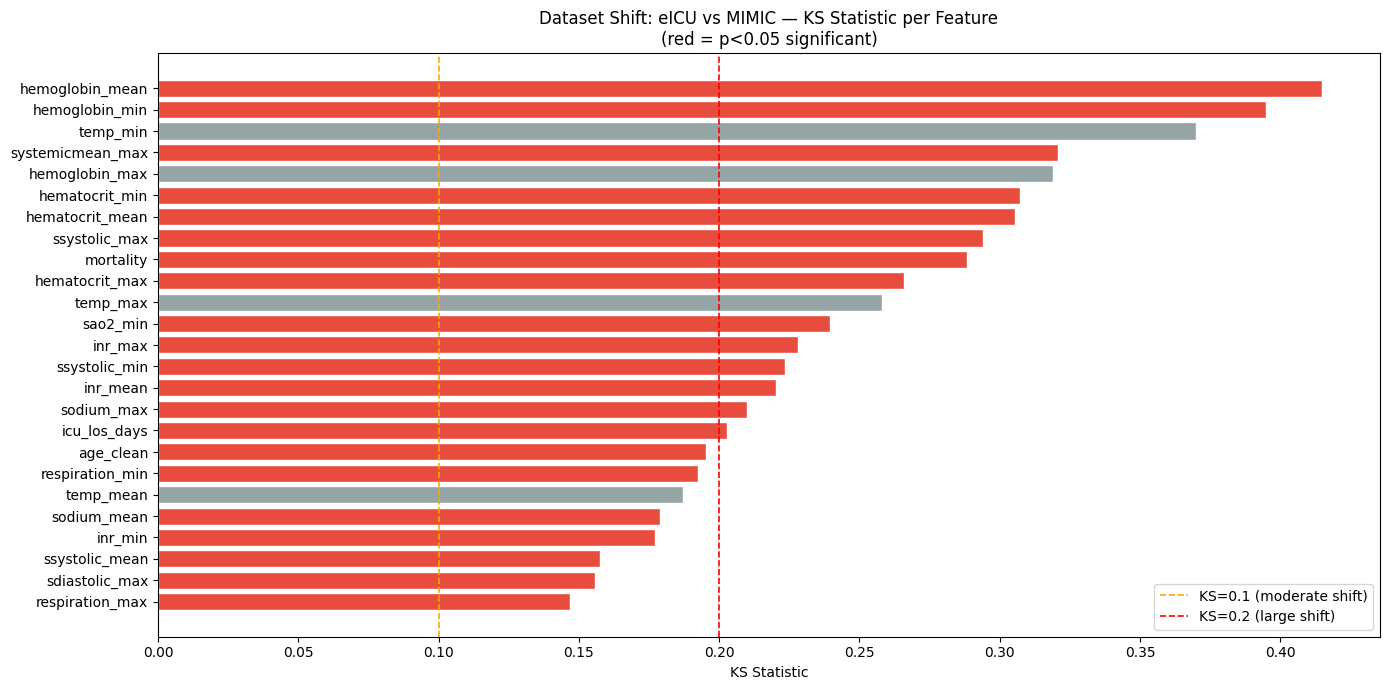

In [33]:
fig, ax = plt.subplots(figsize=(14, 7))
top_ks = ks_df.head(25)
colors = ['#e74c3c' if s else '#95a5a6' for s in top_ks['significant']]
bars = ax.barh(top_ks['feature'][::-1], top_ks['ks_stat'][::-1], color=colors[::-1], edgecolor='white')
ax.axvline(0.1, color='orange', linestyle='--', linewidth=1.2, label='KS=0.1 (moderate shift)')
ax.axvline(0.2, color='red',    linestyle='--', linewidth=1.2, label='KS=0.2 (large shift)')
ax.set_xlabel('KS Statistic')
ax.set_title('Dataset Shift: eICU vs MIMIC — KS Statistic per Feature\n(red = p<0.05 significant)')
ax.legend()
plt.tight_layout()
plt.show()

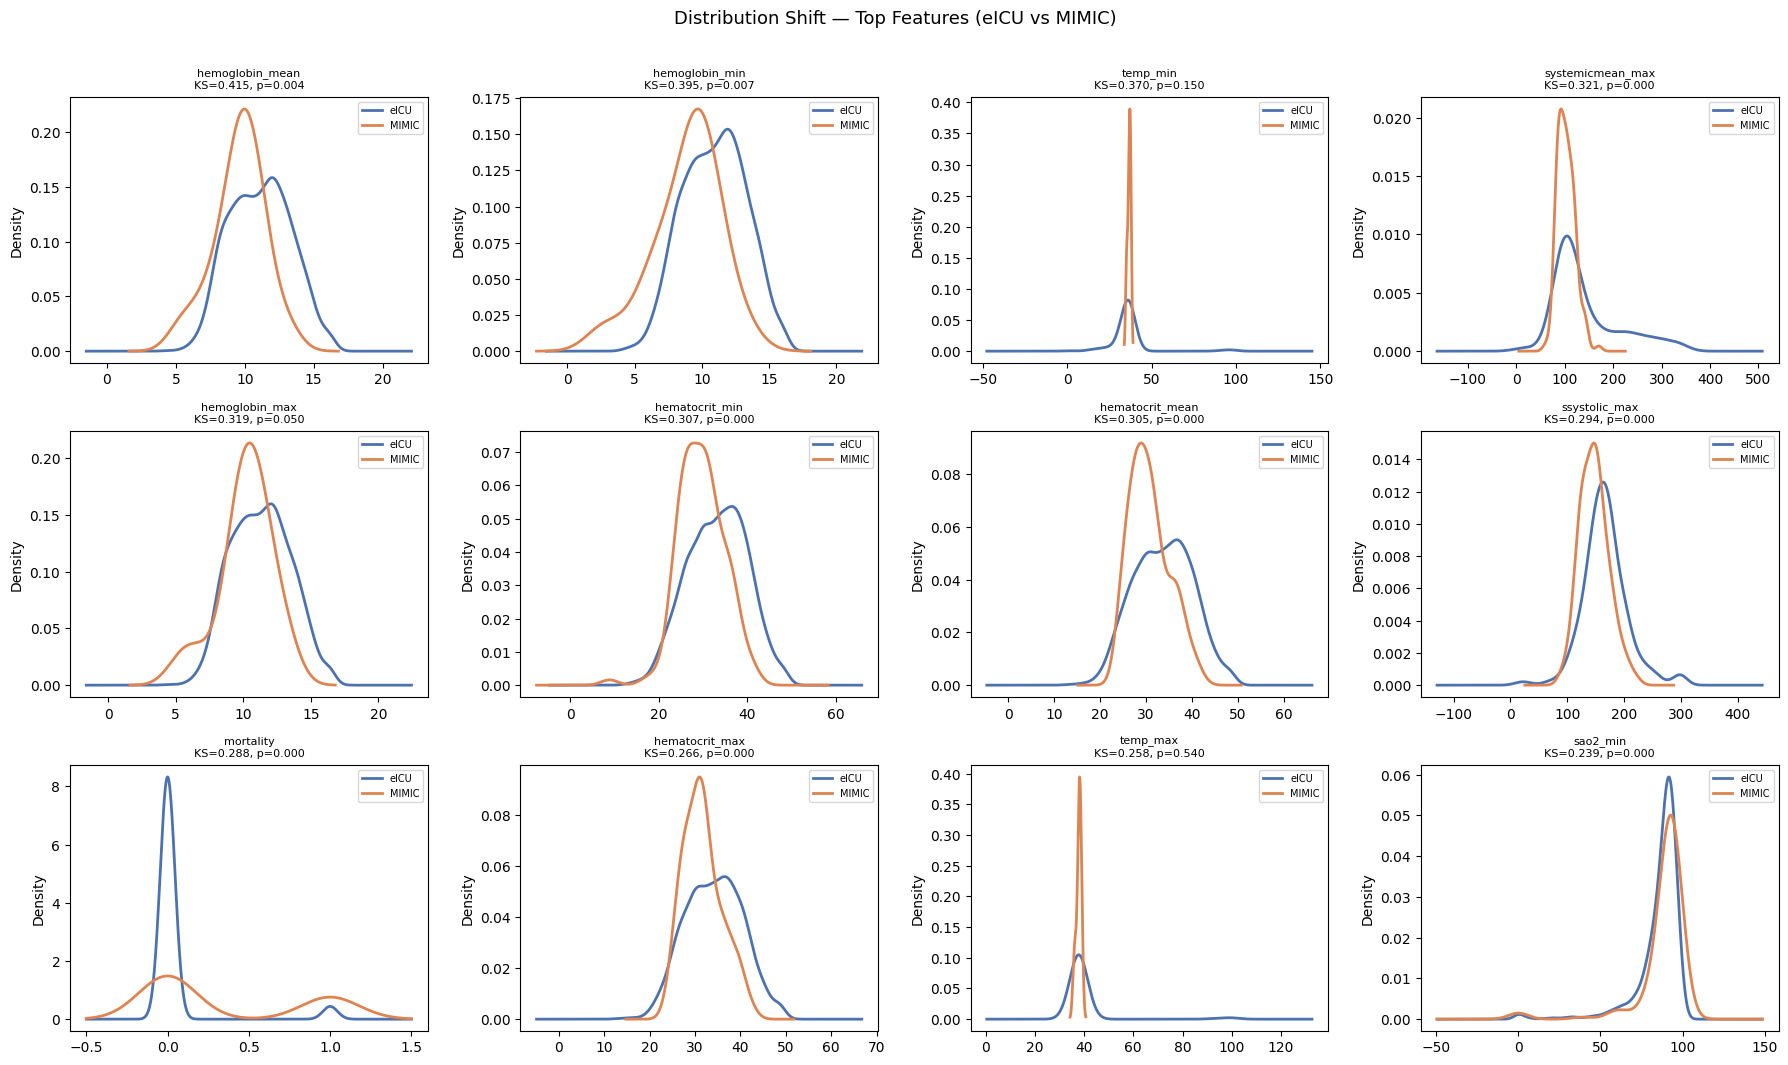

In [34]:
# KDE overlay for top-shifted features
top_shift_cols = ks_df.head(12)['feature'].tolist()

n_cols = 4
n_rows = int(np.ceil(len(top_shift_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(top_shift_cols):
    ax = axes[i]
    e = pd.to_numeric(df_eicu[col], errors='coerce').dropna()
    m = pd.to_numeric(df_mimic_aligned[col], errors='coerce').dropna()

    cap = max(e.quantile(0.99), m.quantile(0.99)) if len(m) else e.quantile(0.99)
    e.clip(upper=cap).plot.kde(ax=ax, color=PALETTE['eICU'],  label='eICU',  linewidth=2)
    m.clip(upper=cap).plot.kde(ax=ax, color=PALETTE['MIMIC'], label='MIMIC', linewidth=2)

    ks_row = ks_df[ks_df['feature'] == col].iloc[0]
    ax.set_title(f'{col}\nKS={ks_row["ks_stat"]:.3f}, p={ks_row["p_value"]:.3f}', fontsize=8)
    ax.legend(fontsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribution Shift — Top Features (eICU vs MIMIC)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

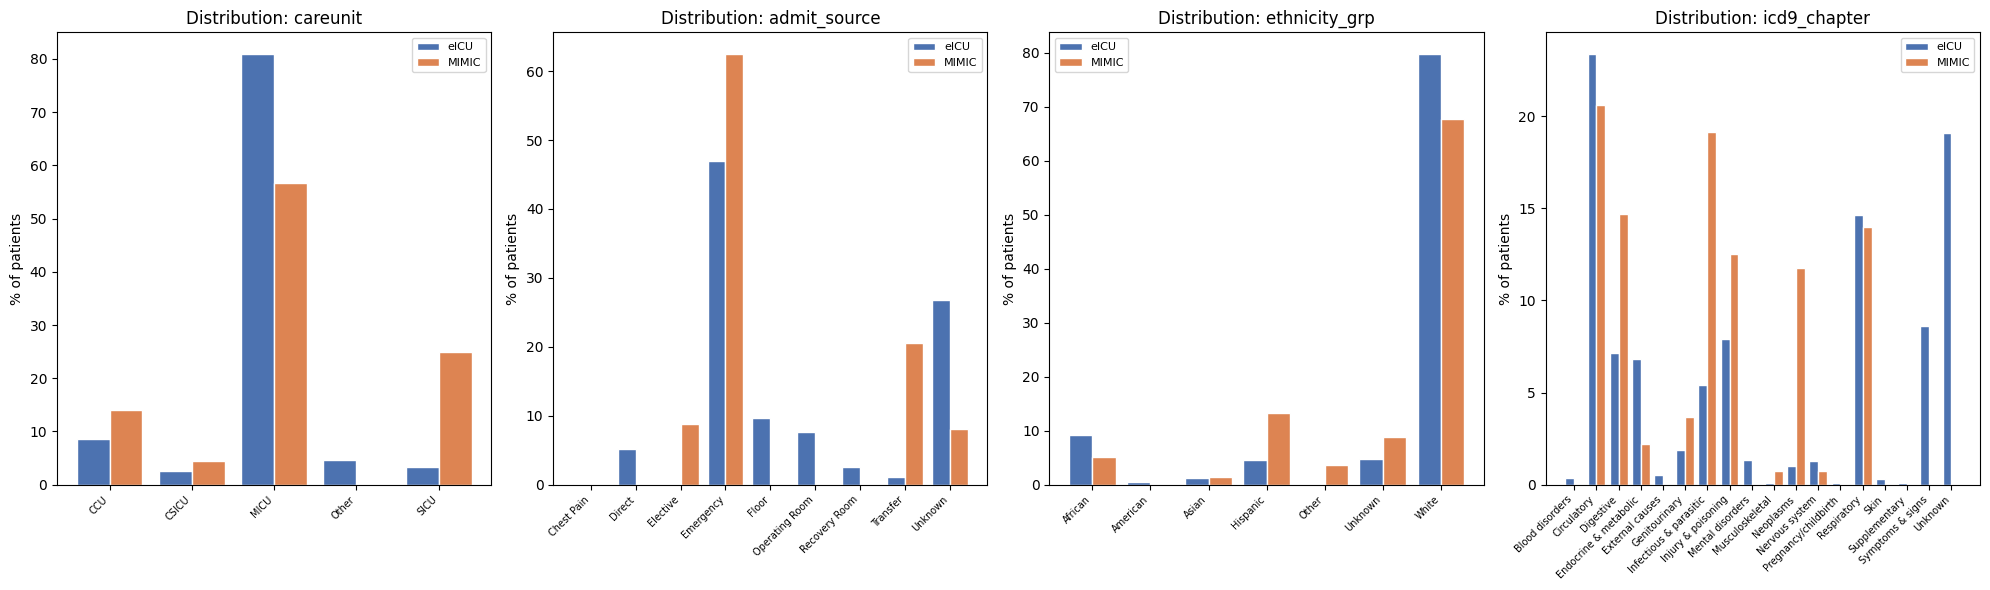

In [35]:
# Categorical shift: compare proportions
CAT_SHARED = [c for c in ['careunit', 'admit_source', 'ethnicity_grp', 'icd9_chapter']
              if c in df_eicu.columns and c in df_mimic_aligned.columns]

fig, axes = plt.subplots(1, len(CAT_SHARED), figsize=(20, 6))

for ax, col in zip(axes, CAT_SHARED):
    e_pct = df_eicu[col].value_counts(normalize=True) * 100
    m_pct = df_mimic_aligned[col].value_counts(normalize=True) * 100
    all_cats = sorted(set(e_pct.index) | set(m_pct.index))
    e_vals = [e_pct.get(c, 0) for c in all_cats]
    m_vals = [m_pct.get(c, 0) for c in all_cats]

    x = np.arange(len(all_cats))
    w = 0.4
    ax.bar(x - w/2, e_vals, w, label='eICU',  color=PALETTE['eICU'],  edgecolor='white')
    ax.bar(x + w/2, m_vals, w, label='MIMIC', color=PALETTE['MIMIC'], edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(all_cats, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('% of patients')
    ax.set_title(f'Distribution: {col}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
# Summary & Key Findings

| Aspect | Finding |
|---|---|
| **Dataset sizes** | eICU: 2,520 patients; MIMIC: 135 patients |
| **Class imbalance** | eICU ~5% mortality; MIMIC varies — heavily imbalanced in both |
| **Evaluation metric** | Must use AUROC / AUPRC / Sensitivity — Accuracy is misleading |
| **Missingness** | Labs (albumin, lactate, ALT) have high missingness (>50%) — imputation required |
| **Lab predictors** | Creatinine, BUN, lactate, bicarbonate most correlated with mortality |
| **Vital predictors** | Min systolic BP, min SpO2, max respiration rate most associated with death |
| **Dataset shift** | Some lab/vital distributions differ between eICU and MIMIC — external validation performance may be lower than internal |
| **Demographics** | Age and care unit significantly predict mortality; ICU/critical care units have highest rates |

